## 0. Imports

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from rapidfuzz import process

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA



## 1. Data Loading

- First, we upload the Excel file with 3 sheets
- Second, we extract the sheets into separate dataframes:
  - `df_species` corresponds to the ESPECES sheet
  - `df_gps` corresponds to the GPS-MILIEU sheet
  - `df_obs` corresponds to the NOM Français sheet, which contains the observations (hence the name df_obs)

In [168]:
file_path = "../data/raw/Observations 2012-2025.xlsx"
#retrieve the number of sheets
print("number of sheets:", pd.ExcelFile(file_path).sheet_names)

df_species = pd.read_excel(file_path, sheet_name='ESPECES', header=None, usecols=[2, 3, 4])
df_species.columns = ['french_name', 'scientific_name', 'status']
# df_species.isna().sum()
# status has a missing value
df_species.head()

df_gps = pd.read_excel(file_path, sheet_name='GPS-MILIEU', header=1, usecols=[2, 3, 4, 5, 6, 7])
df_gps.columns = ['transect', 'X', 'Y', 'habitat', 'transect_id', 'point_id']
# df_gps.isna().sum()
# 0 missing values
df_gps.head()

df_obs = pd.read_excel(file_path, sheet_name='NOM FRANÇAIS', skiprows=[0, 1], header=0)
df_obs.columns = [
        'observer',              # Observer name
        'dept_code',             # Department code  
        'transect',              # Transect name
        'date',                  # Date
        'visit_number',          # 1st, 2nd or 3rd visit
        'clouds',                # Cloud cover
        'rain',                  # Rain intensity
        'wind',                  # Wind strength
        'visibility',            # Visibility
        'point',                 # Point number
        'start_time',            # Start time
        'species',               # Species name
        
        # Contact distances
        'auditory_0_25m',       
        'visual_0_25m',        
        'auditory_25_50m',       
        'visual_25_50m',   
        'auditory_50_100m', 
        'visual_50_100m',     
        'auditory_100m_plus', 
        'visual_100m_plus',   
        
        # Flight
        'flight',
        
        # Totals (4 columns)
        'auditory_total',   
        'visual__no_flight_total',         
        'auditory_visual_no_flight_total',
        'auditory_visual_with_flight_total',
        
        #Notes
        'Notes'
]
df_obs['date'] = pd.to_datetime(df_obs['date'])
df_obs.head()

number of sheets: ['ESPECES', 'GPS-MILIEU', 'NOM FRANÇAIS']


,observer,dept_code,transect,date,visit_number,clouds,rain,wind,visibility,point,...,auditory_50_100m,visual_50_100m,auditory_100m_plus,visual_100m_plus,flight,auditory_total,visual__no_flight_total,auditory_visual_no_flight_total,auditory_visual_with_flight_total,Notes
0,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1,1.0,NaN
1,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1,1.0,NaN
2,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,0.0,2.0,2,2.0,NaN
3,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1,1.0,NaN
4,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1,1.0,NaN


## 2. Data coherence   

In [169]:
def spelling_correction(df_source, df_reference, column_name, similarity_threshold=90):
    """
    Corrects spelling variations in a column by matching against a reference dataframe.
    
    Parameters:
    -----------
    df_source : pd.DataFrame
        The dataframe containing values that need correction
    df_reference : pd.DataFrame
        The dataframe containing the reference/correct values
    column_name : str
        The name of the column to correct in both dataframes
    similarity_threshold : int, optional (default=90)
        Minimum similarity score (0-100) to consider a match. 
        100 = exact match, 90+ = probable match
    
    Returns:
    --------
    dict
        Mapping of original values to corrected values
    """
    df_source[column_name] = df_source[column_name].str.strip().str.lower()
    df_reference[column_name] = df_reference[column_name].str.strip().str.lower()
    
    source_values = df_source[column_name].unique()
    reference_values = df_reference[column_name].unique()

    mapping = {}
    for source_val in source_values:
        match, score, _ = process.extractOne(source_val, reference_values) #Based on levenshtein's distance
        if similarity_threshold <= score < 100:
            mapping[source_val] = match
            print(f"Correction: '{source_val}' -> '{match}' (score={score})")

    # Apply corrections
    df_source[column_name] = df_source[column_name].replace(mapping)
    return mapping


def check_coherence(df_species, df_gps, df_obs): 
    obs_transects = set(df_obs['transect'].str.strip().str.lower().unique())
    gps_transects = set(df_gps['transect'].str.strip().str.lower().unique())
    
    missing_transects = obs_transects - gps_transects
    
    if missing_transects:
        print("Transects in observations but not in GPS data:")
        for transect in sorted(missing_transects):
            print(f"  - {transect}")
        # Correction of the spelling errors
        transect_mapping = spelling_correction(df_obs, df_gps, 'transect', similarity_threshold=90)
    else:
        print("All observation transects have corresponding GPS data")
    
    
#df_species_cp = df_species.copy() 
#df_gps_cp = df_gps.copy() 
#df_obs_cp = df_obs.copy()
check_coherence(df_species, df_gps, df_obs)
check_coherence(df_species, df_gps, df_obs)

Transects in observations but not in GPS data:
  - desmarinière
Correction: 'desmarinière' -> 'desmarinières' (score=96.0)
All observation transects have corresponding GPS data


In [170]:
df_obs_merged = df_obs.merge(
        df_species, 
        left_on='species', 
        right_on='french_name', 
        how='left',
        suffixes=('', '_species')
    )
#transect_habitat = df_gps.groupby('transect')['habitat'].first().reset_index()
#df_full = df_obs_merged.merge(
#     transect_habitat,
#     on='transect',
#     how='left'
#)
#Un transect peut avoir plusieurs habitats selon les points, on merge donc avec les points

# Extraire le numéro après le P
#df_gps['point'] = df_gps['point_id'].str.extract(r'P(\d+)')[0]
#missing_points = df_gps[df_gps['point'].isna()]
#print(missing_points)

df_gps['point_id'] = df_gps['point_id'].replace('SIPI', 'S1P1')

df_gps['point'] = df_gps['point_id'].str.extract(r'P(\d+)')[0].astype(int)
df_obs['point'] = df_obs['point'].astype(int)

df_full = df_obs_merged.merge(
    df_gps[['transect', 'point', 'X', 'Y', 'habitat']],
    on=['transect', 'point'],
    how='left'
)

## 2. Dataset Structure

In [171]:
# Table dimensions
print("="*60)
print("TABLE DIMENSIONS")
print("="*60)

print(f"\n1. SPECIES table:")
print(f"   - {len(df_species)} species")
print(f"   - {df_species['status'].nunique()} status categories")

print(f"\n2. GPS-MILIEU table:")
print(f"   - {len(df_gps)} observation points")
print(f"   - {df_gps['transect'].nunique()} transects")
print(f"   - {df_gps['habitat'].nunique()} habitat types")

print(f"\n3. OBSERVATIONS table:")
print(f"   - {len(df_obs):,} raw observations")
print(f"   - {len(df_full):,} enriched observations")
print(f"   - {df_full.shape[1]} columns")

TABLE DIMENSIONS

1. SPECIES table:
   - 87 species
   - 8 status categories

2. GPS-MILIEU table:
   - 650 observation points
   - 65 transects
   - 7 habitat types

3. OBSERVATIONS table:
   - 114,495 raw observations
   - 115,304 enriched observations
   - 32 columns


## DATA CLEANUP

In [172]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115304 entries, 0 to 115303
Data columns (total 32 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   observer                           115304 non-null  object        
 1   dept_code                          115302 non-null  float64       
 2   transect                           115304 non-null  object        
 3   date                               115304 non-null  datetime64[ns]
 4   visit_number                       115304 non-null  int64         
 5   clouds                             115303 non-null  object        
 6   rain                               115303 non-null  float64       
 7   wind                               115287 non-null  float64       
 8   visibility                         115303 non-null  float64       
 9   point                              115304 non-null  int64         
 10  start_time          

#### Species Names
We remove rows where the species is unknown, as species identification is what we aim to predict. Therefore, we cannot replace these missing values—doing so would defeat the purpose of building our predictive model.

#### Species Status
We notice that the bird species 'Astrild à joues orange' is missing its status. Since this study was conducted in Martinique and Guadeloupe (department codes 971 and 972), and knowing that this specific bird is African by origin, we can directly deduce that it is "Exogène introduit par l'homme" in our dataset.

In [173]:
#Drop si on ne sait pas ce qui a été observé
df_full = df_full.dropna(subset=['french_name', 'scientific_name'], how='all')

# Set a status for 'Astrild à joues orange'
df_full.loc[df_full['french_name'] == "Astrild à joues orange", 'status'] = 'Exogène introduit par l\'homme'

#### Replace NaN Departments

Replace all NaN department values with the department number of their corresponding transect, since each transect is located in only one department (IN OUR DATASET, thanks to the assertion below).

In [174]:
for transect in df_full[df_full['dept_code'].isna()]['transect']:
    # Get the unique non null dept_code for this transect
    unique_dept = df_full[df_full['transect'] == transect]['dept_code'].dropna().unique()
    
    # Assert there's exactly one unique dept_code per transect
    assert len(unique_dept) == 1, f"Expected 1 unique dept_code for transect '{transect}', but found {len(unique_dept)}: {unique_dept}"
    
    # Fill NaN values with this dept_code
    df_full.loc[df_full['transect'] == transect, 'dept_code'] = df_full.loc[df_full['transect'] == transect, 'dept_code'].fillna(unique_dept[0])

In [175]:
# Remplacer les valeurs manquantes dans clouds, rain, wind, visibility (itératif avec RandomForest)

cols_to_impute = ['clouds', 'rain', 'wind', 'visibility']

for c in cols_to_impute:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')


# Si TOUTES les variables météo sont manquantes pour une ligne → on met tout à 0
mask_all_nan = df_full[cols_to_impute].isna().all(axis=1)
df_full.loc[mask_all_nan, cols_to_impute] = 0

# Sinon, on peut faire une imputation plus fine pour les lignes partiellement manquantes
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    max_iter=10,
    random_state=42
)

df_full.loc[~mask_all_nan, cols_to_impute] = imputer.fit_transform(
    df_full.loc[~mask_all_nan, cols_to_impute]
)

print(df_full[cols_to_impute].isna().sum())

df_full

clouds        0
rain          0
wind          0
visibility    0
dtype: int64


,observer,dept_code,transect,date,visit_number,clouds,rain,wind,visibility,point,...,visual__no_flight_total,auditory_visual_no_flight_total,auditory_visual_with_flight_total,Notes,french_name,scientific_name,status,X,Y,habitat
0,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1,1.0,NaN,Sucrier à ventre jaune,Coereba flaveola martinicana,Autochtone,706274,1624126,Forêt humide
1,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,1.0,1,1.0,NaN,Sporophile cici,Melanospiza bicolor ou Tiaris bicolor,Autochtone,706274,1624126,Forêt humide
2,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,2.0,2,2.0,NaN,Colibri falle-vert,Eulampis h. holosericeus,Endémique des Petites Antilles,706274,1624126,Forêt humide
3,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1,1.0,NaN,Elénie siffleuse,Elaenia m. martinica,Autochtone,706274,1624126,Forêt humide
4,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1,1.0,NaN,Coulicou manioc,Coccyzus minor,Autochtone,706274,1624126,Forêt humide
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115299,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,2,2.0,NaN,Sporophile rougegorge,Loxigilla n. noctis,Endémique des Petites Antilles,708778,1621356,Périurbain
115300,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,1,1.0,NaN,Saltator gros-bec,Saltator a. albicollis,Autochtone,708778,1621356,Périurbain
115301,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,2,2.0,NaN,Sucrier à ventre jaune,Coereba flaveola martinicana,Autochtone,708778,1621356,Périurbain
115302,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,3,3.0,NaN,Viréo à moustaches,Vireo altiloquus barbadensis,Autochtone,708778,1621356,Périurbain


In [176]:
# remplacer les valeurs manquantes dans les colonnes de comptage par 0 + recalcul des totaux

auditory_cols = ['auditory_0_25m', 'auditory_25_50m', 'auditory_50_100m', 'auditory_100m_plus']
visual_cols = ['visual_0_25m', 'visual_25_50m', 'visual_50_100m', 'visual_100m_plus']
flight = ['flight']
for c in auditory_cols + visual_cols + flight:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')
    
df_full[ auditory_cols + visual_cols + flight] = df_full[ auditory_cols + visual_cols + flight].fillna(0)

df_full.head()

totals = ['auditory_total', 'visual__no_flight_total', 'auditory_visual_no_flight_total', 'auditory_visual_with_flight_total']
for c in totals:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')
    
df_full['auditory_total'] = df_full[auditory_cols].sum(axis=1)
df_full['visual__no_flight_total'] = df_full[visual_cols].sum(axis=1)
df_full['auditory_visual_no_flight_total'] = df_full[auditory_cols + visual_cols].sum(axis=1)
df_full['auditory_visual_with_flight_total'] = df_full[auditory_cols + visual_cols + ['flight']].sum(axis=1)

In [177]:
nan_cols = df_full.columns[df_full.isna().any()]
print(df_full[nan_cols].isna().sum())

Notes    103212
dtype: int64


In [179]:
nan_cols = df_full.columns[df_full.isna().any()]
print(df_full[nan_cols].isna().sum())

Notes    103212
dtype: int64


In [180]:
df_full['Notes'].unique()


array([nan, 'en formation  SOPHIE Stéphane/ ELY-MARIUS Séverine',
       'Compagnonnage par Beatriz Conde  ', 'Banane 100% coupé',
       "Beaucoup d'ordure et carcasse de voiture",
       'Camping de plusiers personnes sur ce site',
       'Végetation très secs', 'COMPAGNONNAGE PAR BEATRIZ CONDE',
       'CARCASSE DE VOITURE',
       'Les PRODOM ont trouvé un nouveau site de nidification la toiture du lycée',
       'Canne 100% coupé', 'Canne 70% coupé', "Aménagement d'un parking",
       'DORTOIRE', 'Canne à sucre  100% coupé', 'Canne à sucre 50% coupé',
       'FAIT PAR BEATRIZ CONDE', "Accompagner par Caroll-Ann' Portel",
       'AU NID',
       'Oiseau dans la peripherie du camps de canne- Canne a sucre basse',
       'Canne basse', 'Sans canne 50% et canne à sucre basse 50%',
       'Pas de canne', 'Bassin de traitement',
       'COMPAGNONAGE AVEC B.CONDE', "SUR L'ILET BOISSEAU",
       "Presence d'iguane", 'Compagnonnage par Beatriz CONDE',
       'COMPAGNONNAGE PAR BEATRIZ COND

## Clustering : Regroupons les espèces qui ont des profils similaires de détection et d’habitat.

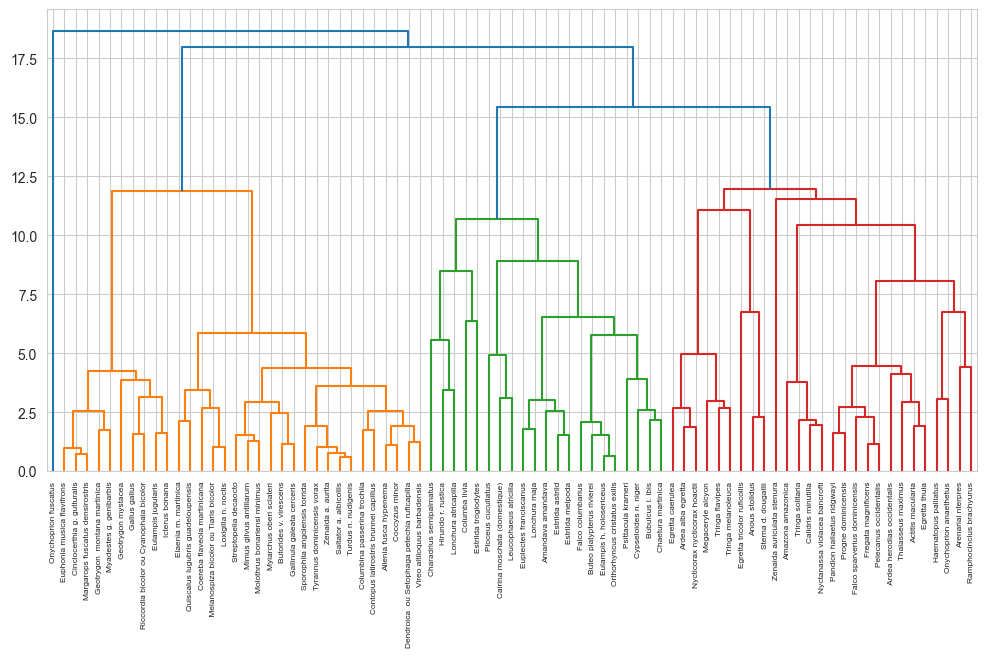

In [181]:
detection_cols = [
    'auditory_0_25m', 'auditory_25_50m', 'auditory_50_100m', 'auditory_100m_plus',
    'visual_0_25m', 'visual_25_50m', 'visual_50_100m', 'visual_100m_plus',
    'flight'
]

habitat_dummies = pd.get_dummies(df_full['habitat'], prefix='habitat')
df_cluster = pd.concat([df_full[detection_cols], habitat_dummies], axis=1)

df_species_cluster = df_cluster.groupby(df_full['scientific_name']).mean()



scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_species_cluster)

Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=df_species_cluster.index, leaf_rotation=90)
plt.show()

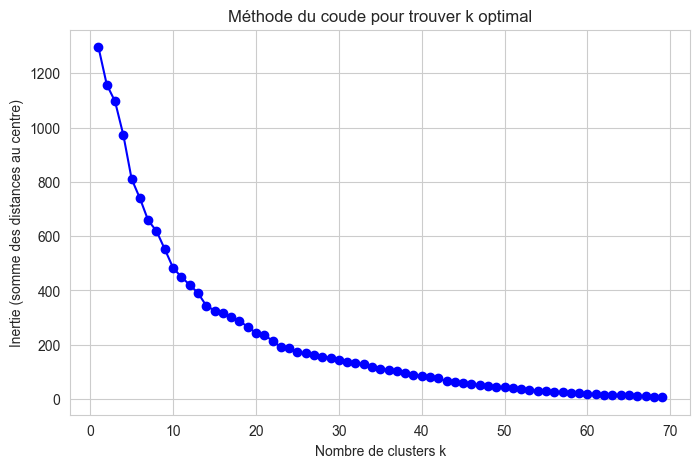

In [182]:
inertia = []
K = range(1, 70)  # tester de 1 à 14 clusters
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances au centre)')
plt.title('Méthode du coude pour trouver k optimal')
plt.show()


C:\Users\zizou\AppData\Local\Temp\ipykernel_20820\3647295126.py:12: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



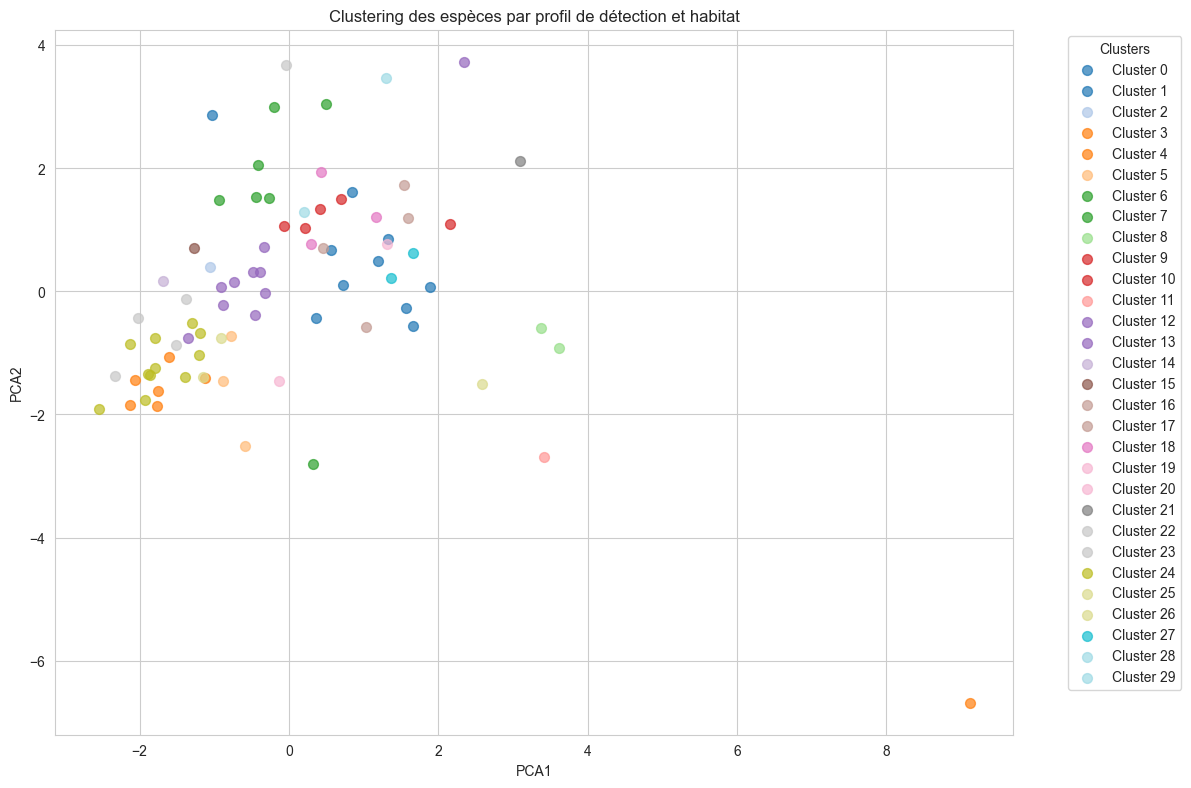

In [183]:
# Réduction à 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=30, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12,8))

n_clusters = len(np.unique(clusters))
# Palette de couleurs continue
colors = cm.get_cmap('tab20', n_clusters)  # 'tab20' permet plus de couleurs, interpolé si >20

for cluster_id in range(n_clusters):
    mask = clusters == cluster_id
    plt.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        color=colors(cluster_id),
        label=f'Cluster {cluster_id}',
        s=50, alpha=0.7
    )

plt.xlabel('PCA1')
plt.ylabel('PCA2')
#for i, name in enumerate(df_species_cluster.index):
#    plt.text(X_pca[i,0], X_pca[i,1], name, fontsize=8)
plt.title('Clustering des espèces par profil de détection et habitat')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')  # légende à droite
plt.tight_layout()
plt.show()


## Cartes

In [165]:
df_map = df_full.dropna(subset=['X', 'Y', 'habitat'])

habitats = df_map['habitat'].unique()

colors = plt.cm.get_cmap('tab20', len(habitats))
habitat_color = {hab: colors(i) for i, hab in enumerate(habitats)}
species = df_map['french_name'].unique()
species_colors = plt.cm.get_cmap('tab20b', len(species))
species_color = {sp: species_colors(i) for i, sp in enumerate(species)}

plt.figure(figsize=(14, 12))

# Plot habitat circles
df_map_grouped = df_map.groupby(['transect', 'habitat'])
for (transect, hab), df_h in df_map_grouped:
    center_x = df_h['X'].mean()
    center_y = df_h['Y'].mean()
    radius = max(np.sqrt((df_h['X'] - center_x)**2 + (df_h['Y'] - center_y)**2))
    
    circle = plt.Circle((center_x, center_y), radius, 
                        color=habitat_color[hab], alpha=0.3, label=hab)
    plt.gca().add_patch(circle)

# Plot species points with names
for sp in species:
    df_sp = df_map[df_map['french_name'] == sp]
    plt.scatter(df_sp['X'], df_sp['Y'], 
                color=species_color[sp], s=20, label=sp)
    
    # Add text labels for each observation
    for idx, row in df_sp.iterrows():
        plt.text(row['X'], row['Y'], sp, 
                fontsize=6, 
                color=species_color[sp],
                ha='left', 
                va='bottom',
                alpha=0.7)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Observations d'oiseaux superposées aux habitats par transect")

# Legend without duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), markerscale=2, fontsize=8)

plt.axis('equal')
plt.show()

C:\Users\zizou\AppData\Local\Temp\ipykernel_20820\2853721661.py:5: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

C:\Users\zizou\AppData\Local\Temp\ipykernel_20820\2853721661.py:8: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x000002185E31A980> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000002186FF967A0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

# Tentatives plus esthétiques (pas au point)

In [144]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Sélection des top observateurs/transects
top_observers = df_full['observer'].value_counts().nlargest(10).index
top_transects = df_full['transect'].value_counts().nlargest(10).index

df_small = df_full[df_full['observer'].isin(top_observers) & 
            df_full['transect'].isin(top_transects)].copy()

# Créer total_detections et year
df_small['total_detections'] = df_small['auditory_total'].fillna(0) + df_small['visual__no_flight_total'].fillna(0)
df_small['year'] = df_small['date'].dt.year

# Fit GLM
model = smf.glm("total_detections ~ observer + transect + year",
                data=df_small,
                family=sm.families.Poisson()).fit()

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:       total_detections   No. Observations:                16904
Model:                            GLM   Df Residuals:                    16891
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -31509.
Date:                Mon, 03 Nov 2025   Deviance:                       20532.
Time:                        17:22:49   Pearson chi2:                 2.98e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01923
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [145]:
df_full.head()

,observer,dept_code,transect,date,visit_number,clouds,rain,wind,visibility,point,...,visual__no_flight_total,auditory_visual_no_flight_total,auditory_visual_with_flight_total,Notes,french_name,scientific_name,status,X,Y,habitat
0,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1.0,1.0,NaN,Sucrier à ventre jaune,Coereba flaveola martinicana,Autochtone,706274,1624126,Forêt humide
1,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,1.0,1.0,1.0,NaN,Sporophile cici,Melanospiza bicolor ou Tiaris bicolor,Autochtone,706274,1624126,Forêt humide
2,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,2.0,2.0,2.0,NaN,Colibri falle-vert,Eulampis h. holosericeus,Endémique des Petites Antilles,706274,1624126,Forêt humide
3,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1.0,1.0,NaN,Elénie siffleuse,Elaenia m. martinica,Autochtone,706274,1624126,Forêt humide
4,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1.0,1.0,NaN,Coulicou manioc,Coccyzus minor,Autochtone,706274,1624126,Forêt humide


# Answering the questions

# 1.Descreptive analysis

## 1.1 Overview on Dataset's Structure

In the sections below, we present:

- Dataset dimensions and temporal coverage.
- Unique identifiers.
- Correlation matrix, in order to see the key columns.

Results: 
- We can clearly see that most numerical columns are independent, which makes them all important for our statistical modeling.
- We observe high correlation between total values and distance-specific measurements (auditory_0_25m, etc.), which is expected since the former are the sum of the latter.
- We also notice correlation between visibility and cloud cover, which is logical and confirms the internal coherence of the dataset.

STRUCTURE DU DATASET
Dimensions : 114,088 observations × 34 colonnes
Période : 2014-03-29 to 2025-07-03
Années : 2014 - 2025 (12 années)

Identifiants uniques :
  - Transects : 65
  - Points d'écoute : 10
  - Observateurs : 49
  - Espèces : 81
  - Habitats : 7
  - Départements : 41




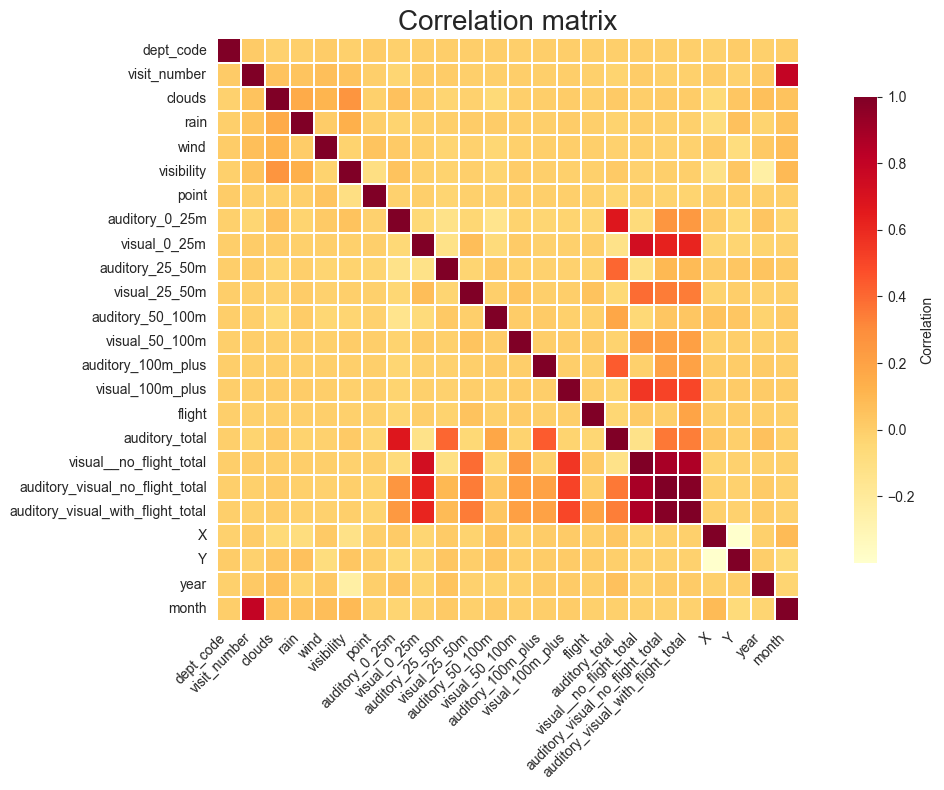

In [184]:
import seaborn as sns

# Configuration graphiques
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Convertir date en datetime si nécessaire
df_full['date'] = pd.to_datetime(df_full['date'])
df_full['year'] = df_full['date'].dt.year
df_full['month'] = df_full['date'].dt.month

# Vue d'ensemble
print("="*60)
print("STRUCTURE DU DATASET")
print("="*60)
print(f"Dimensions : {df_full.shape[0]:,} observations × {df_full.shape[1]} colonnes")
print(f"Période : {df_full['date'].min().date()} to {df_full['date'].max().date()}")
print(f"Années : {df_full['year'].min()} - {df_full['year'].max()} ({df_full['year'].nunique()} années)")
print(f"\nIdentifiants uniques :")
print(f"  - Transects : {df_full['transect'].nunique()}")
print(f"  - Points d'écoute : {df_full['point'].nunique()}")
print(f"  - Observateurs : {df_full['observer'].nunique()}")
print(f"  - Espèces : {df_full['scientific_name'].nunique()}")
print(f"  - Habitats : {df_full['habitat'].nunique()}")
print(f"  - Départements : {df_full['dept_code'].nunique()}")
print("\n")

#=============== Correlation matrix to retrieve key columns ===============
# Select numerical columns
numerical_cols = df_full.select_dtypes(include=[np.number]).columns

# Calculate covariance matrix
corr_m = df_full[numerical_cols].corr()
# Visualize with diagonal highlighted
plt.figure(figsize=(12, 8))
sns.heatmap(corr_m, 
            annot=False,  # Remove numbers
            cmap='YlOrRd',
            square=True,
            linewidths=0.2,
            cbar_kws={"label": "Correlation", "shrink": 0.8})
plt.title('Correlation matrix', fontsize=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

## 1.2 Descriptive statics over relevant variables

### 1.2.1 Counts
In section below we are showing
- Distribution of key categorical variables (transects, habitats, species status)
- Coefficient of Variation (CV) analysis to assess information content across numerical columns

transect
morne babet                  2902
habitation petite rivière    2839
moulin à vent                2825
là-haut                      2380
hôtel des plaisirs           2372
autre bord                   2336
borelie                      2283
fond rousseau                2232
jeannot                      2211
o'mullane                    2208
Name: count, dtype: int64

habitat
Forêt sèche     26960
Agricole        26817
Périurbain      24718
Forêt humide    20433
Plage            5750
Mangrove         5481
Urbain           3929
Name: count, dtype: int64

status
Autochtone                        77261
Endémique des Petites Antilles    19958
Exogène colonisateur naturel      10426
Exogène introduit par l'homme      4533
Migrateur                           999
Marin                               478
Endémique de la Martinique          433
Name: count, dtype: int64

COEFFICIENT OF VARIATION - INFORMATION CONTENT ANALYSIS
                           Column         Mean          Std      

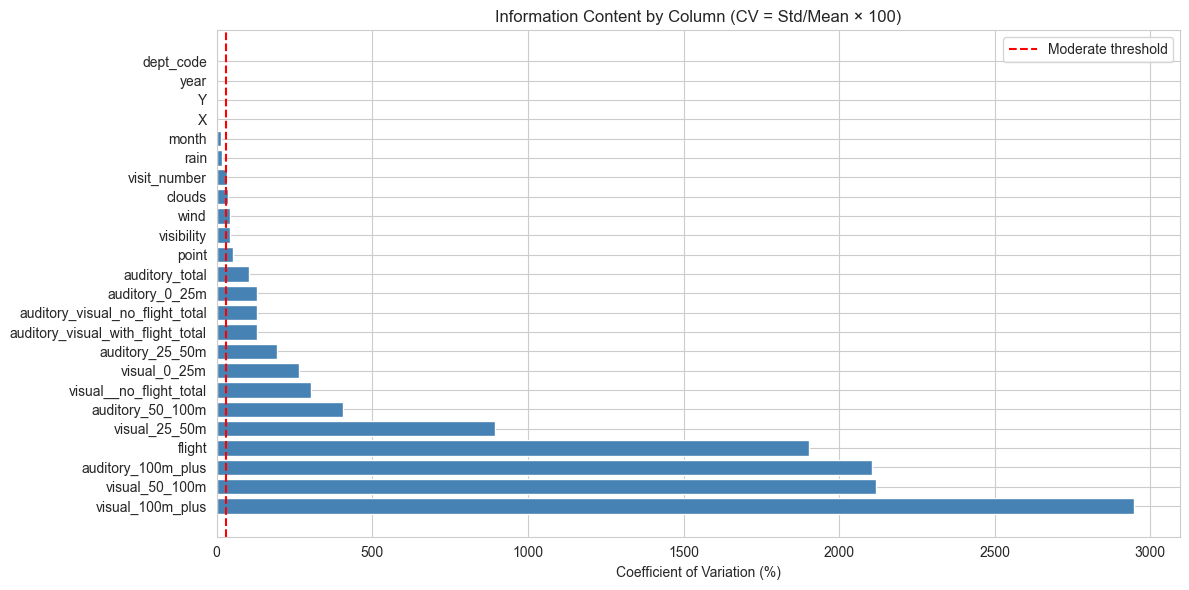

In [185]:
# Liste des éléments
print(df_full['transect'].value_counts().head(10), end="\n\n")
print(df_full['habitat'].value_counts(), end="\n\n")
print(df_full['status'].value_counts(), end="\n\n")



# Select numerical columns from your dataset
numerical_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()

# Calculate Coefficient of Variation for each column
cv_results = []

for col in numerical_cols:
    data = df_full[col].dropna()  # Remove missing values
    
    if len(data) == 0:
        cv_results.append({
            'Column': col,
            'Mean': np.nan,
            'Std': np.nan,
            'CV': np.nan,
            'Non-missing': 0,
            'Info_Content': 'No data'
        })
        continue
    
    mean_val = data.mean()
    std_val = data.std()
    
    # Coefficient of Variation (handle division by zero)
    if mean_val != 0:
        cv = (std_val / abs(mean_val)) * 100  # As percentage
    else:
        cv = np.inf if std_val > 0 else 0
    
    # Categorize information content
    if cv == 0:
        info = 'No variation (constant)'
    elif cv < 10:
        info = 'Low variation'
    elif cv < 30:
        info = 'Moderate variation'
    elif cv < 100:
        info = 'High variation'
    else:
        info = 'Very high variation'
    
    cv_results.append({
        'Column': col,
        'Mean': mean_val,
        'Std': std_val,
        'CV (%)': cv,
        'Non-missing': len(data),
        'Info_Content': info
    })

# Create DataFrame
cv_df = pd.DataFrame(cv_results).sort_values('CV (%)', ascending=False)

print("=" * 80)
print("COEFFICIENT OF VARIATION - INFORMATION CONTENT ANALYSIS")
print("=" * 80)
print(cv_df.to_string(index=False))
print("\n")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# CV by column
cv_df_clean = cv_df[cv_df['CV (%)'].notna() & np.isfinite(cv_df['CV (%)'])]
ax.barh(cv_df_clean['Column'], cv_df_clean['CV (%)'], color='steelblue')
ax.set_xlabel('Coefficient of Variation (%)')
ax.set_title('Information Content by Column (CV = Std/Mean × 100)')
ax.axvline(30, color='red', linestyle='--', label='Moderate threshold')
ax.legend()

plt.tight_layout()
plt.show()

### 1.2.2 Observer efforts

In [186]:
# ============= EFFORT ANNUEL =============
print("\n" + "="*60)
print("EFFORT D'OBSERVATION PAR ANNÉE")
print("="*60)

effort_annual = df_full.groupby('year').agg({
    'transect': 'nunique',
    'point': 'nunique',
    'visit_number': 'max',
    'observer': 'nunique',
    'date': 'count'
}).rename(columns={
    'transect': 'nb_transects',
    'point': 'nb_points',
    'visit_number': 'max_visits',
    'observer': 'nb_observers',
    'date': 'nb_observations'
})

print(effort_annual)


EFFORT D'OBSERVATION PAR ANNÉE
      nb_transects  nb_points  max_visits  nb_observers  nb_observations
year                                                                    
2014            41         10           2            24             5276
2015            53         10           2            27             7980
2016            59         10           2            29            10852
2017            60         10           2            27             9172
2018            64         10           2            24             9687
2019            64         10           2            23             9537
2020            63         10           2            15            10017
2021            63         10           2            13            10662
2022            63         10           2            15            10857
2023            64         10           2            15            10216
2024            64         10           2            24            10031
2025            65 

In [187]:
# Nombre de points-visites uniques par an
effort_annual['points_visits'] = df_full.groupby('year').apply(
    lambda x: x[['transect', 'point', 'visit_number']].drop_duplicates().shape[0]
).values

print("\nPoints-visites par année :")
print(effort_annual['points_visits'])


Points-visites par année :
year
2014     768
2015    1051
2016    1140
2017    1168
2018    1248
2019    1246
2020    1148
2021    1254
2022    1259
2023    1237
2024    1262
2025    1269
Name: points_visits, dtype: int64


C:\Users\zizou\AppData\Local\Temp\ipykernel_20820\2655115687.py:2: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [188]:
# ============= EFFORT PAR TRANSECT =============
print("\n" + "="*60)
print("EFFORT PAR TRANSECT")
print("="*60)

effort_transect = df_full.groupby('transect').agg({
    'date': ['count', 'nunique'],
    'year': 'nunique',
    'point': 'nunique',
    'observer': 'nunique'
})
effort_transect.columns = ['nb_obs', 'nb_dates', 'nb_years', 'nb_points', 'nb_observers']
effort_transect = effort_transect.sort_values('nb_obs', ascending=False)
print(effort_transect)


EFFORT PAR TRANSECT
                              nb_obs  nb_dates  nb_years  nb_points  \
transect                                                              
morne babet                     2902        24        12         10   
habitation petite rivière       2839        26        12         10   
moulin à vent                   2825        24        12         10   
là-haut                         2380        23        12         10   
hôtel des plaisirs              2372        23        12         10   
...                              ...       ...       ...        ...   
ilets du françois               1112        16         9         10   
route forestière de palourde    1049        21        11         10   
galion 2                         887        18         9         10   
forêt vatable 2                  886        15         8         10   
bois pothau                      132         2         1         10   

                              nb_observers  
transect  

In [189]:
# ============= SAISONNALITÉ =============
effort_monthly = df_full.groupby(['year', 'month']).size().reset_index(name='nb_obs')

In the heatmap, we would like to order transects in lexicographic order of their X, Y coordinates. This way, we will be able to see how the sampling effort is distributed geographically.

Results: 
- We have noticed that some locations have more observations than others, which can introduce bias into our study.
- The transect "Point de la rose" had almost no observations between 2014 and 2016, contrarywise to the "Desmarinières" transect had many observations throughout the years.

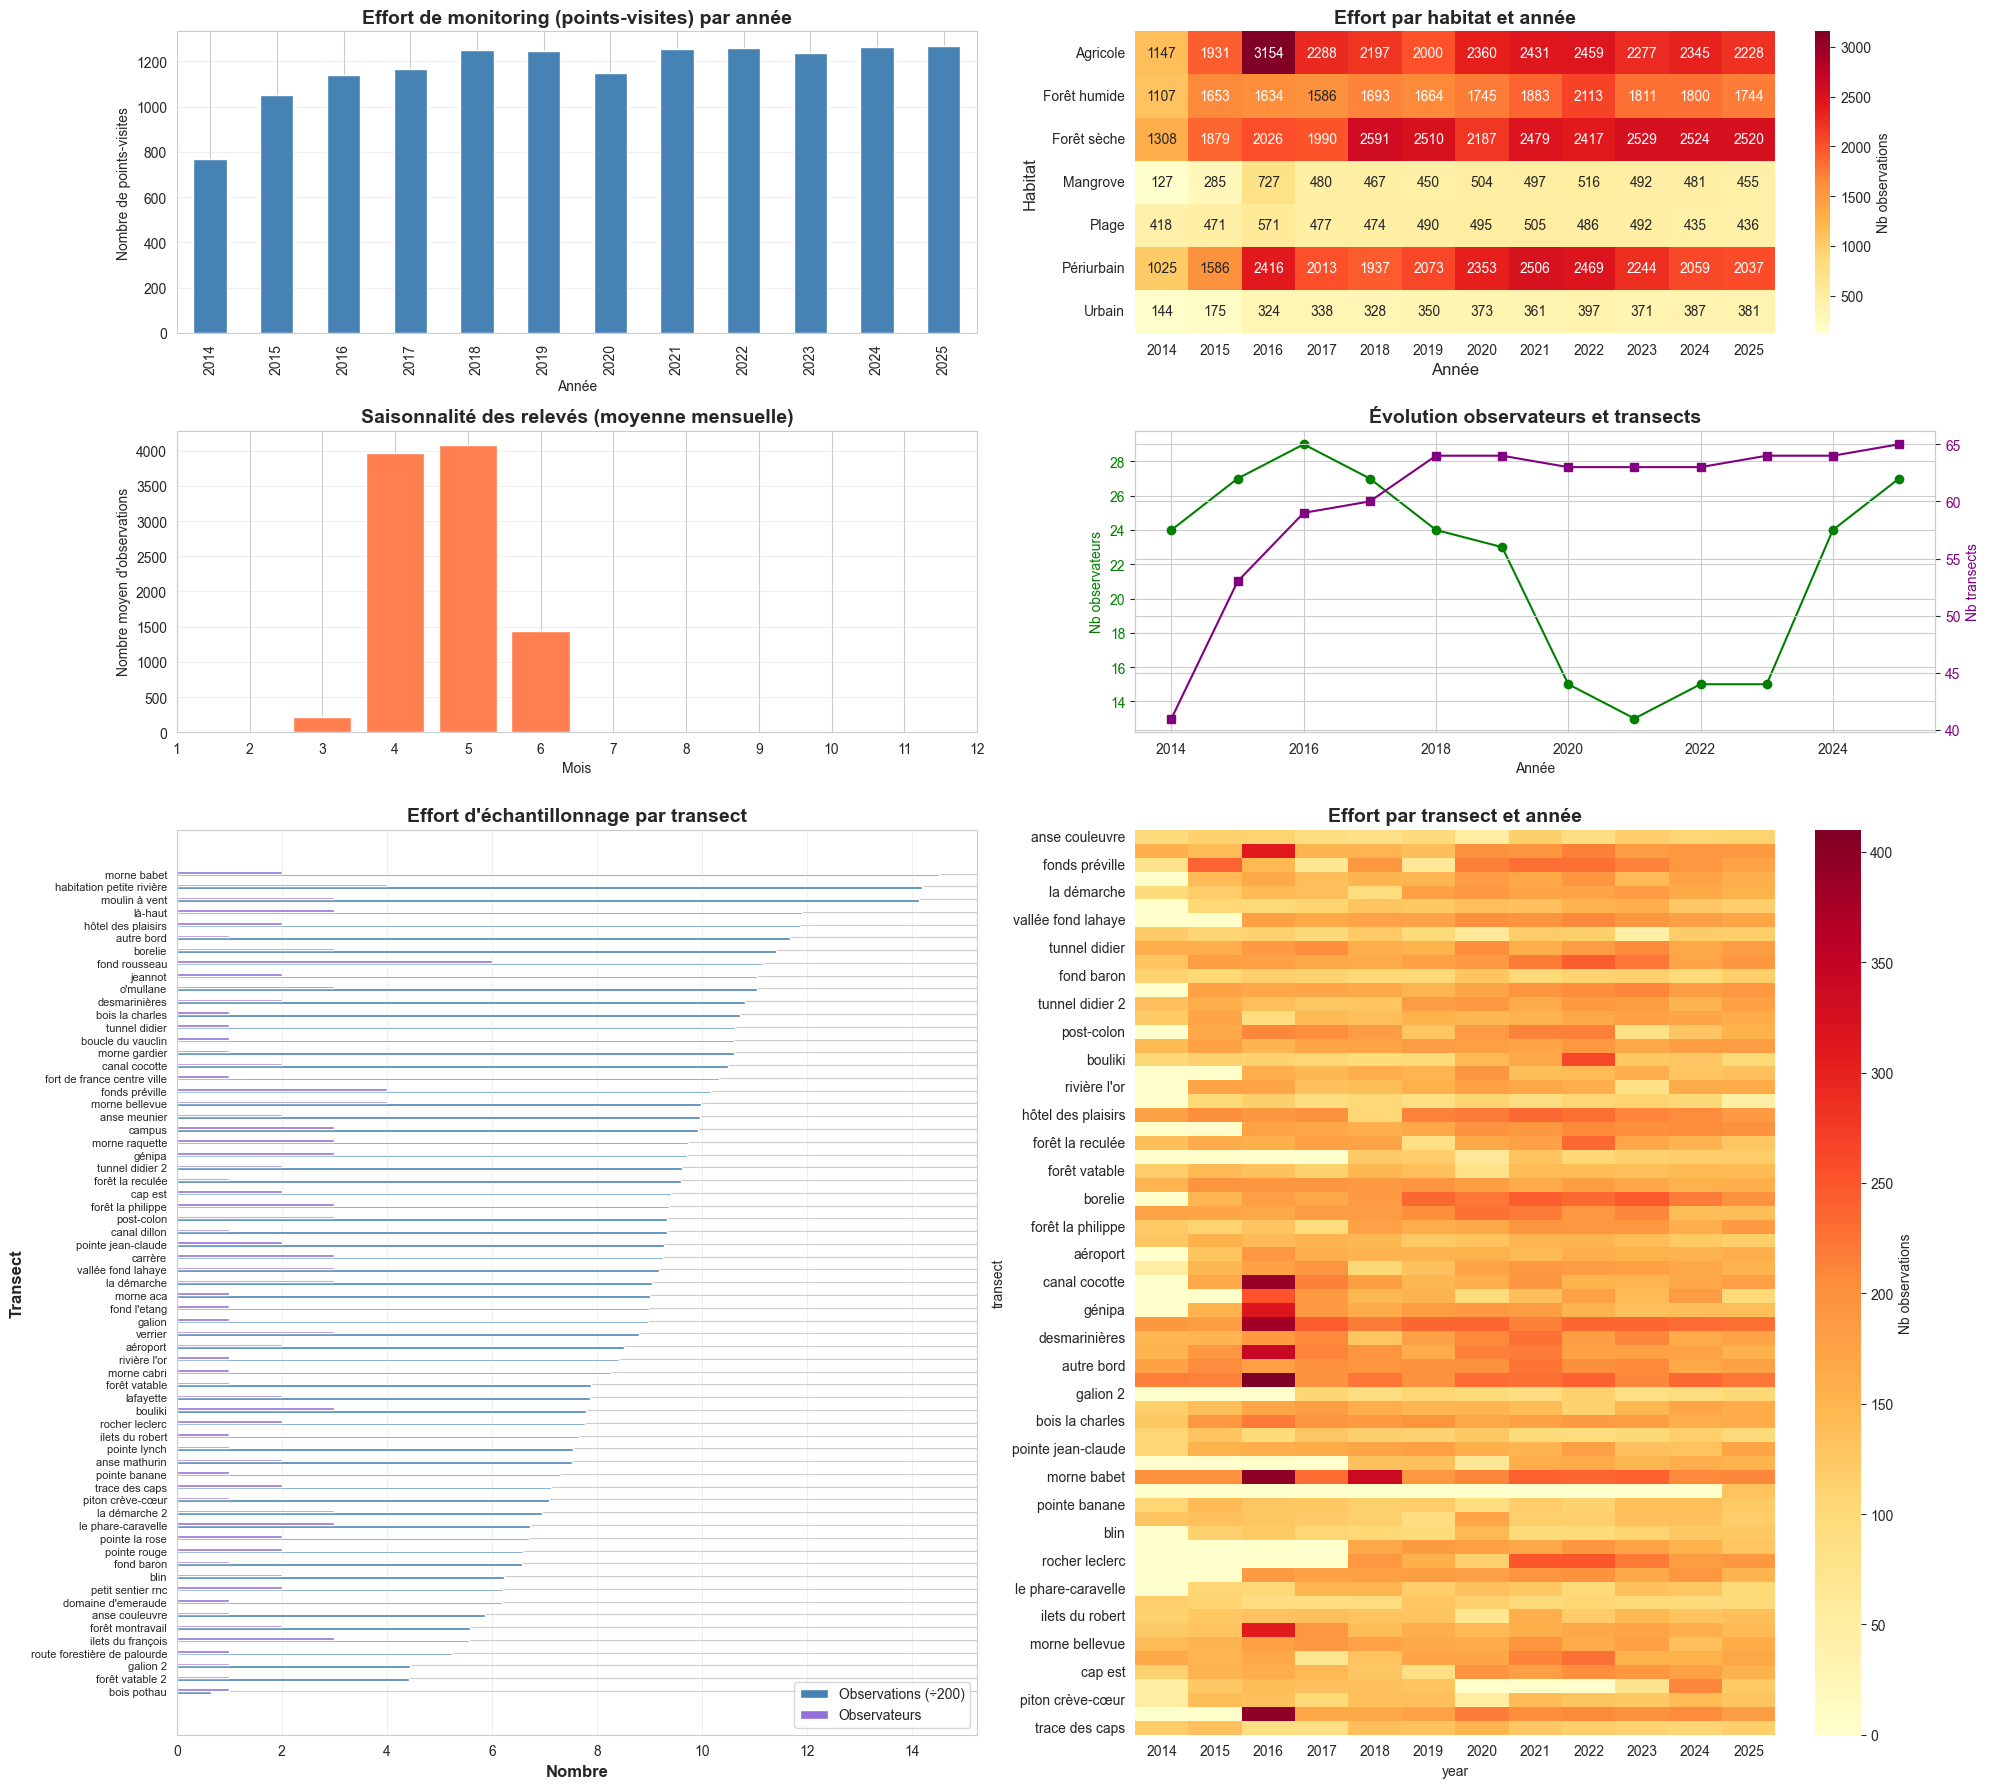

In [190]:
# ============= VISUALISATIONS EFFORT =============
fig = plt.figure(figsize=(20, 18))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 3])  # Ligne 3 deux fois plus grande

ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
ax20 = fig.add_subplot(gs[2, 0])
ax21 = fig.add_subplot(gs[2, 1])

# Évolution annuelle
effort_annual['points_visits'].plot(kind='bar', ax=ax00, color='steelblue')
ax00.set_title('Effort de monitoring (points-visites) par année', fontsize=14, fontweight='bold')
ax00.set_xlabel('Année')
ax00.set_ylabel('Nombre de points-visites')
ax00.grid(axis='y', alpha=0.3)

# Heatmap transects X années
transect_coords = df_full.groupby('transect').agg({
    'X': 'first',
    'Y': 'first'
}).reset_index()
transect_coords = transect_coords.sort_values(['X', 'Y'])
transect_order = transect_coords['transect'].tolist()

pivot_transect = df_full.groupby(['transect', 'year']).size().reset_index(name='count')
pivot_transect = pivot_transect.pivot(index='transect', columns='year', values='count').fillna(0)
pivot_transect = pivot_transect.reindex(transect_order)

sns.heatmap(pivot_transect, cmap='YlOrRd', ax=ax21, cbar_kws={'label': 'Nb observations'})
ax21.set_title('Effort par transect et année', fontsize=14, fontweight='bold')

# Saisonnalité
monthly_avg = effort_monthly.groupby('month')['nb_obs'].mean()
ax10.bar(monthly_avg.index, monthly_avg.values, color='coral')
ax10.set_title('Saisonnalité des relevés (moyenne mensuelle)', fontsize=14, fontweight='bold')
ax10.set_xlabel('Mois')
ax10.set_ylabel('Nombre moyen d\'observations')
ax10.set_xticks(range(1, 13))
ax10.grid(axis='y', alpha=0.3)

# Évolution nb observateurs et transects
effort_annual['nb_observers'].plot(ax=ax11, marker='o', label='Observateurs', color='green')
ax11.set_ylabel('Nb observateurs', color='green')
ax11.tick_params(axis='y', labelcolor='green')

ax11_twin = ax11.twinx()
effort_annual['nb_transects'].plot(ax=ax11_twin, marker='s', label='Transects', color='purple')
ax11_twin.set_ylabel('Nb transects', color='purple')
ax11_twin.tick_params(axis='y', labelcolor='purple')

ax11.set_title('Évolution observateurs et transects', fontsize=14, fontweight='bold')
ax11.set_xlabel('Année')

# Effort par transect
effort_sorted = effort_transect.sort_values('nb_obs', ascending=True)
x = np.arange(len(effort_sorted))
width = 0.2

ax20.barh(x - 0.5*width, effort_sorted['nb_obs']/200, width, label='Observations (÷200)', color='steelblue')
ax20.barh(x + 0.5*width, effort_sorted['nb_observers'], width, label='Observateurs', color='mediumpurple')

ax20.set_yticks(x)
ax20.set_yticklabels(effort_sorted.index, fontsize=8)
ax20.set_xlabel('Nombre', fontsize=12, fontweight='bold')
ax20.set_ylabel('Transect', fontsize=12, fontweight='bold')
ax20.set_title('Effort d\'échantillonnage par transect', fontsize=14, fontweight='bold')
ax20.legend(loc='lower right', fontsize=10)
ax20.grid(axis='x', alpha=0.3)

# Heatmap habitat X années
pivot_habitat = df_full.groupby(['habitat', 'year']).size().reset_index(name='count')
pivot_habitat = pivot_habitat.pivot(index='habitat', columns='year', values='count').fillna(0)

sns.heatmap(pivot_habitat, cmap='YlOrRd', ax=ax01, cbar_kws={'label': 'Nb observations'}, annot=True, fmt='g')
ax01.set_title('Effort par habitat et année', fontsize=14, fontweight='bold')
ax01.set_xlabel('Année', fontsize=12)
ax01.set_ylabel('Habitat', fontsize=12)

plt.tight_layout()
plt.show()

## 1.2.3 Environmental descriptors (weather)

In [191]:
print("\n" + "="*60)
print("CONDITIONS MÉTÉOROLOGIQUES")
print("="*60)

weather_vars = ['clouds', 'rain', 'wind', 'visibility']
weather_stats = df_full[weather_vars].describe()
print(weather_stats)


CONDITIONS MÉTÉOROLOGIQUES
              clouds           rain           wind     visibility
count  114088.000000  114088.000000  114088.000000  114088.000000
mean        1.968671       1.028925       1.424143       1.417090
std         0.698015       0.176363       0.601033       0.618845
min         0.000000       0.000000      -5.000000       0.000000
25%         1.000000       1.000000       1.000000       1.000000
50%         2.000000       1.000000       1.000000       1.000000
75%         2.000000       1.000000       2.000000       2.000000
max         3.000000       3.000000       3.000000       4.000000


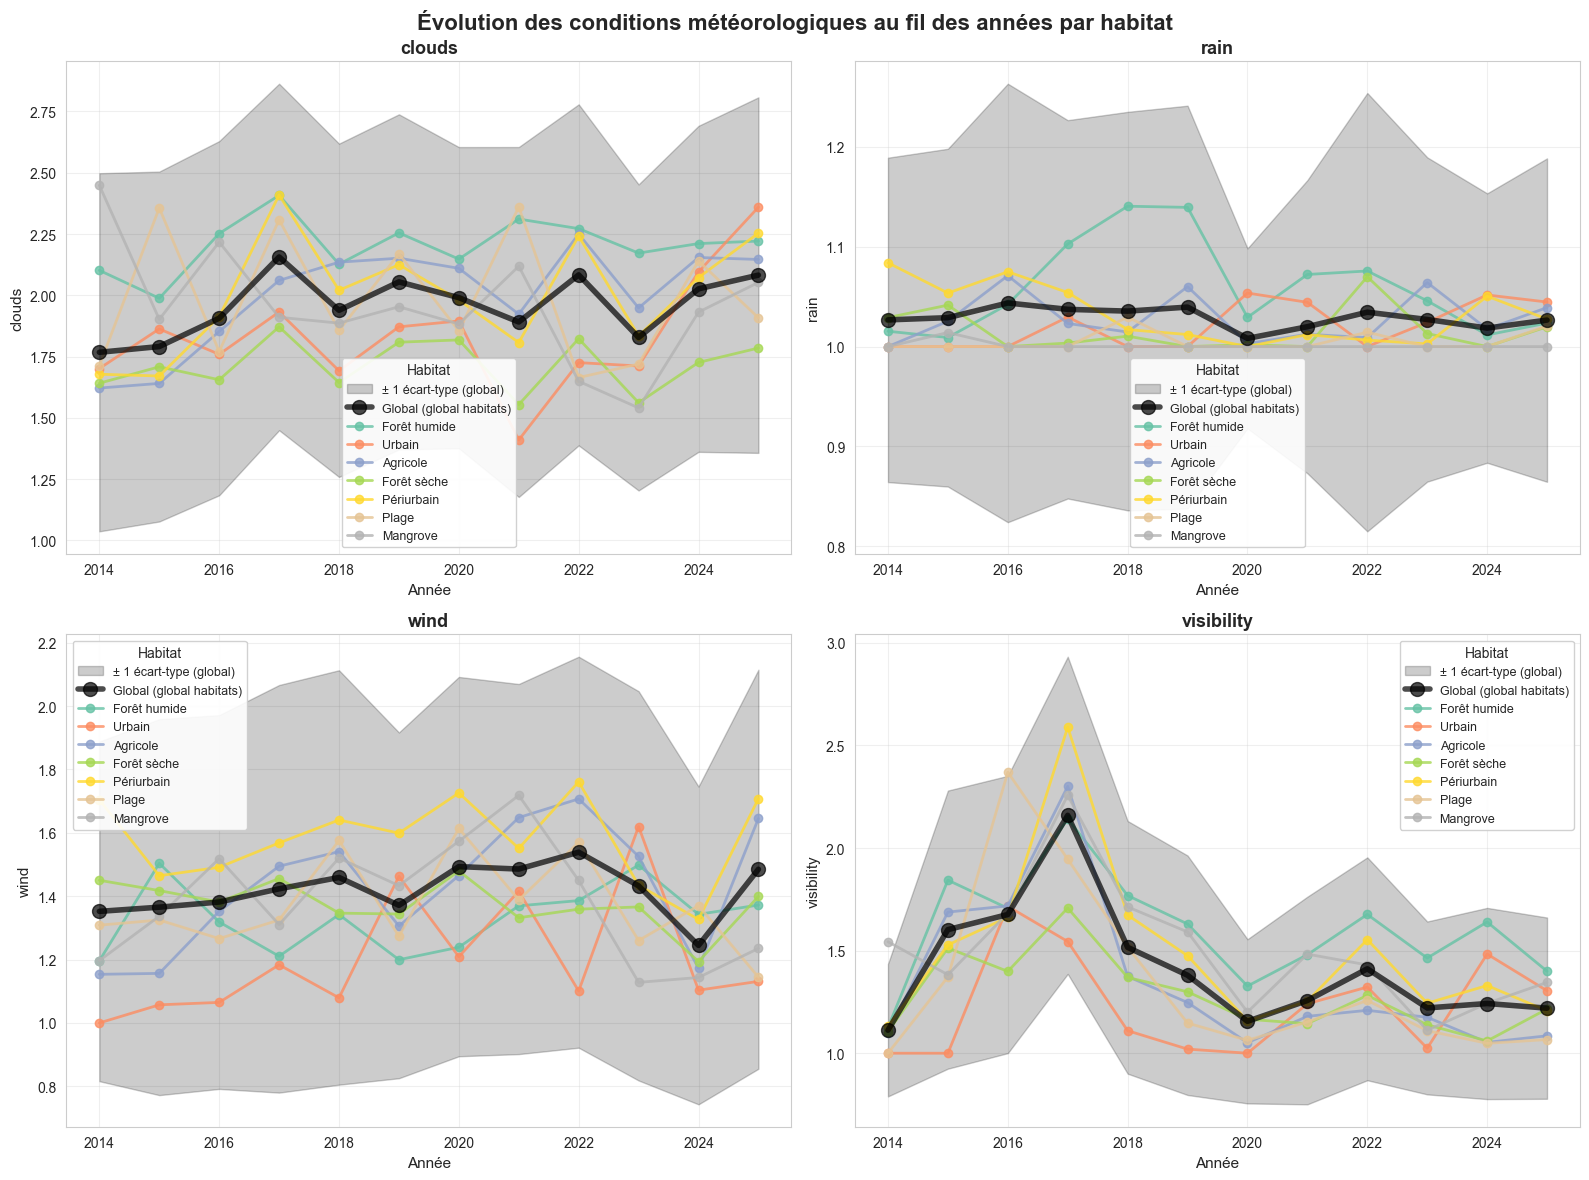

In [192]:
# ============= VISUALISATIONS MÉTÉO - ÉVOLUTION TEMPORELLE PAR HABITAT =============
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Évolution des conditions météorologiques au fil des années par habitat', fontsize=16, fontweight='bold')

# Définir une palette de couleurs pour les habitats
habitats = df_full['habitat'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(habitats)))
habitat_colors = dict(zip(habitats, colors))

for idx, var in enumerate(weather_vars):
    ax = axes[idx//2, idx%2]
    
    # Tracer d'abord la courbe globale (toutes données confondues) en gras avec std
    yearly_global = df_full.groupby('year')[var].agg(['mean', 'std']).reset_index()
    
    # Bande d'écart-type pour la courbe globale
    ax.fill_between(yearly_global['year'], 
                     yearly_global['mean'] - yearly_global['std'], 
                     yearly_global['mean'] + yearly_global['std'], 
                     alpha=0.2, color='black', label='± 1 écart-type (global)')
    
    # Courbe globale en gras
    ax.plot(yearly_global['year'], yearly_global['mean'], 
            marker='o', linewidth=4, label='Global (global habitats)', 
            color='black', markersize=10, zorder=10, alpha=0.7)
    
    # Pour chaque habitat, tracer la moyenne
    for habitat in habitats:
        df_habitat = df_full[df_full['habitat'] == habitat]
        
        # Calculer la moyenne annuelle par habitat
        yearly_mean = df_habitat.groupby('year')[var].mean().reset_index()
        
        # Tracer uniquement la moyenne
        ax.plot(yearly_mean['year'], yearly_mean[var], 
                marker='o', linewidth=2, label=habitat, 
                color=habitat_colors[habitat], markersize=6, alpha=0.8)
    
    ax.set_title(f'{var}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Année', fontsize=11)
    ax.set_ylabel(var, fontsize=11)
    ax.legend(loc='best', fontsize=9, framealpha=0.9, title='Habitat')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


COMPTAGES D'OISEAUX

Statistiques auditory_visual_with_flight_total :
count    114088.000000
mean          2.225379
std           2.883633
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max         200.000000
Name: auditory_visual_with_flight_total, dtype: float64

TOP 15 ESPÈCES LES PLUS ABONDANTES
french_name
Quiscale merle                38434.0
Sucrier à ventre jaune        30138.0
Elénie siffleuse              20655.0
Tourterelle à queue carrée    20387.0
Sporophile rougegorge         20103.0
Sporophile cici               14618.0
Tyran gris                    13523.0
Saltator gros-bec             10551.0
Viréo à moustaches             9372.0
Merle à lunettes               9252.0
Astrild ondulé                 8220.0
Héron garde-bœuf               5804.0
Vacher luisant                 4860.0
Pigeon biset domestique        4615.0
Moqueur des savanes            4458.0
Name: auditory_visual_with_flight_total, dtype: float64

MÉTHODES DE DÉ

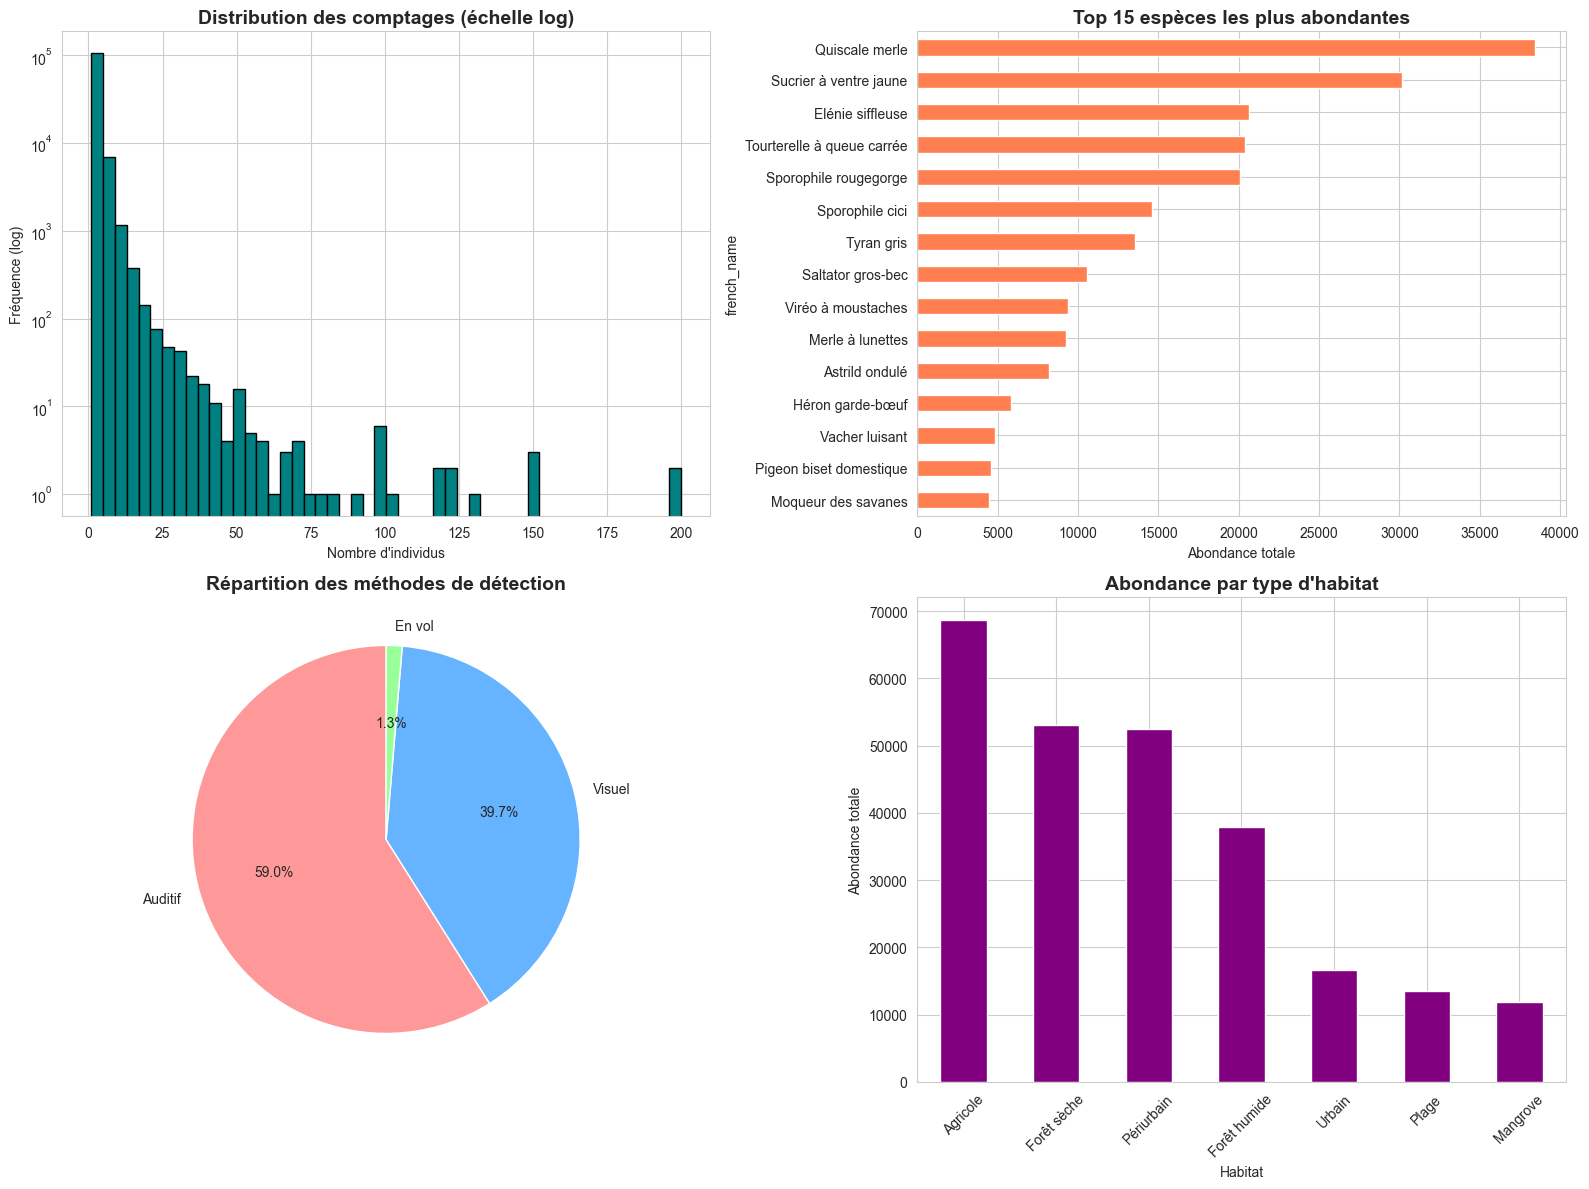

In [193]:
# ============= STATISTIQUES COMPTAGES =============
print("\n" + "="*60)
print("COMPTAGES D'OISEAUX")
print("="*60)

count_var = 'auditory_visual_with_flight_total'
print(f"\nStatistiques {count_var} :")
print(df_full[count_var].describe())

# Top espèces
print("\n" + "="*60)
print("TOP 15 ESPÈCES LES PLUS ABONDANTES")
print("="*60)

top_species = df_full.groupby('french_name')[count_var].sum().sort_values(ascending=False).head(15)
print(top_species)

# Méthodes de détection
total_auditory = df_full['auditory_total'].sum()
total_visual = df_full['visual__no_flight_total'].sum()
total_flight = (df_full['auditory_visual_with_flight_total'] - df_full['auditory_visual_no_flight_total']).sum()

print(f"\n" + "="*60)
print("MÉTHODES DE DÉTECTION")
print("="*60)
print(f"Total auditif : {total_auditory:,} ({total_auditory/(total_auditory+total_visual+total_flight)*100:.1f}%)")
print(f"Total visuel (sans vol) : {total_visual:,} ({total_visual/(total_auditory+total_visual+total_flight)*100:.1f}%)")
print(f"Total en vol : {total_flight:,} ({total_flight/(total_auditory+total_visual+total_flight)*100:.1f}%)")

# ============= VISUALISATIONS COMPTAGES =============
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution comptages (log scale)
axes[0,0].hist(df_full[count_var][df_full[count_var] > 0], bins=50, color='teal', edgecolor='black')
axes[0,0].set_yscale('log')
axes[0,0].set_title('Distribution des comptages (échelle log)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Nombre d\'individus')
axes[0,0].set_ylabel('Fréquence (log)')

# 2. Top espèces
top_species.plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Top 15 espèces les plus abondantes', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Abondance totale')
axes[0,1].invert_yaxis()

# 3. Méthodes de détection (pie chart)
detection_data = [total_auditory, total_visual, total_flight]
detection_labels = ['Auditif', 'Visuel', 'En vol']
axes[1,0].pie(detection_data, labels=detection_labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'])
axes[1,0].set_title('Répartition des méthodes de détection', fontsize=14, fontweight='bold')

# 4. Abondance par habitat
habitat_abundance = df_full.groupby('habitat')[count_var].sum().sort_values(ascending=False)
habitat_abundance.plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Abondance par type d\'habitat', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Habitat')
axes[1,1].set_ylabel('Abondance totale')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig('comptages_oiseaux.png', dpi=300, bbox_inches='tight')
plt.show()

In [194]:
df_full.columns

Index(['observer', 'dept_code', 'transect', 'date', 'visit_number', 'clouds',
       'rain', 'wind', 'visibility', 'point', 'start_time', 'species',
       'auditory_0_25m', 'visual_0_25m', 'auditory_25_50m', 'visual_25_50m',
       'auditory_50_100m', 'visual_50_100m', 'auditory_100m_plus',
       'visual_100m_plus', 'flight', 'auditory_total',
       'visual__no_flight_total', 'auditory_visual_no_flight_total',
       'auditory_visual_with_flight_total', 'Notes', 'french_name',
       'scientific_name', 'status', 'X', 'Y', 'habitat', 'year', 'month'],
      dtype='object')


DÉTECTABILITÉ PAR DISTANCE
  Distance     Count  Percentage
0    0-25m  176404.0       70.41
1   25-50m   51595.0       20.59
2  50-100m   13315.0        5.31
3    100m+    9210.0        3.68


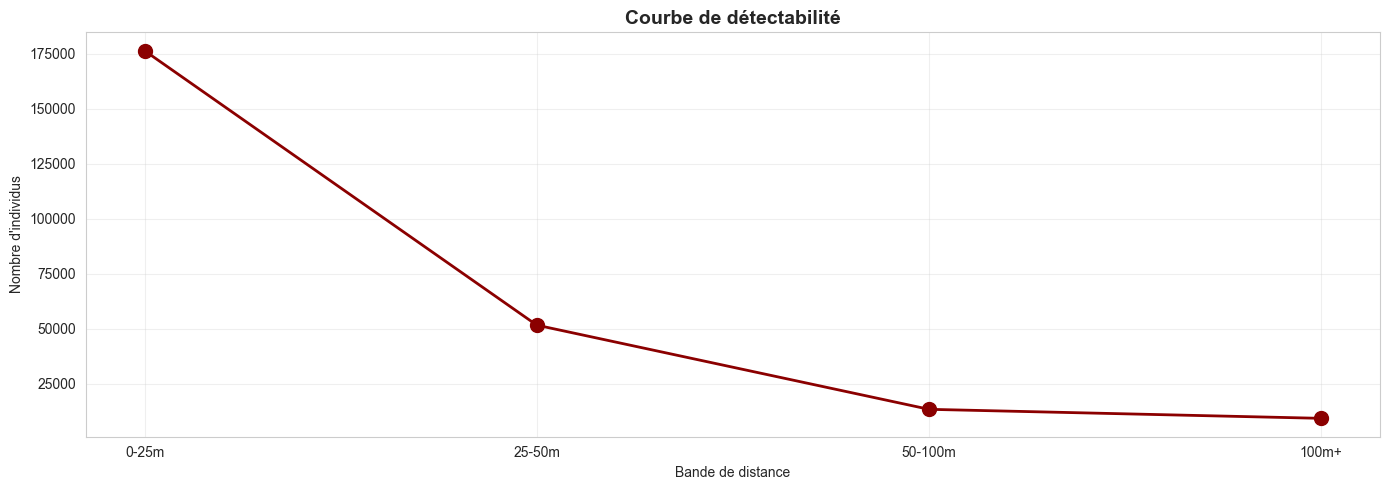

In [195]:
# ============= DÉTECTABILITÉ PAR DISTANCE =============
print("\n" + "="*60)
print("DÉTECTABILITÉ PAR DISTANCE")
print("="*60)

# Par bande de distance
distance_bands = {
    '0-25m': df_full['auditory_0_25m'].sum() + df_full['visual_0_25m'].sum(),
    '25-50m': df_full['auditory_25_50m'].sum() + df_full['visual_25_50m'].sum(),
    '50-100m': df_full['auditory_50_100m'].sum() + df_full['visual_50_100m'].sum(),
    '100m+': df_full['auditory_100m_plus'].sum() + df_full['visual_100m_plus'].sum()
}

distance_df = pd.DataFrame(list(distance_bands.items()), columns=['Distance', 'Count'])
distance_df['Percentage'] = (distance_df['Count'] / distance_df['Count'].sum() * 100).round(2)
print(distance_df)

# Visualisation
fig, axe = plt.subplots(1, 1, figsize=(14, 5))
axe.plot(range(len(distance_df)), distance_df['Count'], marker='o', linewidth=2, markersize=10, color='darkred')
axe.set_title('Courbe de détectabilité', fontsize=14, fontweight='bold')
axe.set_xlabel('Bande de distance')
axe.set_ylabel('Nombre d\'individus')
axe.set_xticks(range(len(distance_df)))
axe.set_xticklabels(distance_df['Distance'])
axe.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('detectabilite_distance.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.3 Discussion about notable data quality considerations
 brouillon
espaces agricoles maintient beaucoup d'espèces, mais attention, c'est aussi l'endroit ou on a fait le plus d'observations

# 1bis. Etudes de Biais 

## 1bis.1 Efforts

### Effort annuel

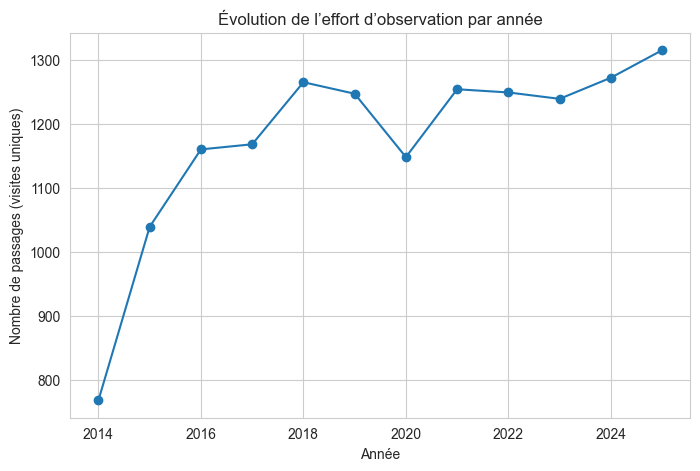

In [210]:
df_effort = (
    df_full
    .drop_duplicates(subset=['observer', 'date', 'transect', 'point'])
    .groupby('year')
    .size()
    .reset_index(name='nb_passages')
)

plt.figure(figsize=(8,5))
plt.plot(df_effort['year'], df_effort['nb_passages'], marker='o')
plt.xlabel("Année")
plt.ylabel("Nombre de passages (visites uniques)")
plt.title("Évolution de l’effort d’observation par année")
plt.grid(True)
plt.show()


La courbe augmente au fil des années -> l'effort s’intensifie (plus d’observations réalisées).

Implication : les modèles qui comparent les années pourraient confondre une augmentation de l’effort avec une augmentation de la biodiversité.
-> Il faut donc corriger en incluant une variable d’effort ou en standardisant par le nombre de visites.

### Effort Saisonnier

In [208]:
df_season = (
    df_full
    .groupby(['month'])
    [['auditory_total', 'visual__no_flight_total']]
    .sum()
    .reset_index()
)
df_season['total_effort'] = df_season['auditory_total'] + df_season['visual__no_flight_total']

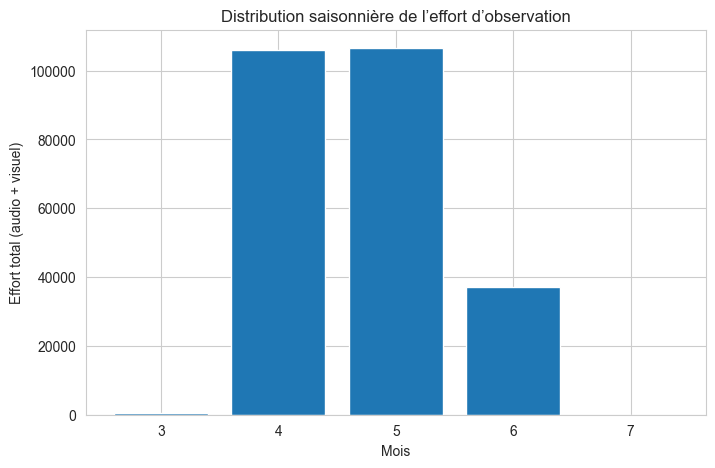

In [209]:
plt.figure(figsize=(8,5))
plt.bar(df_season['month'], df_season['total_effort'])
plt.xlabel("Mois")
plt.ylabel("Effort total (audio + visuel)")
plt.title("Distribution saisonnière de l’effort d’observation")
plt.show()

l’effort est saisonnier, ce qui est normal pour les suivis ornithologiques (période de reproduction).

-Les espèces présentes hors saison seront sous-représentées.

-Il faut tenir compte de la période d’échantillonnage pour faire des comparaisons temporelles ou spatiales,.

-Il faut éviter de tirer des conclusions pour les périodes autres que Avril -> Juin, car nous n’avons pas assez de données pour estimer la richesse réelle.

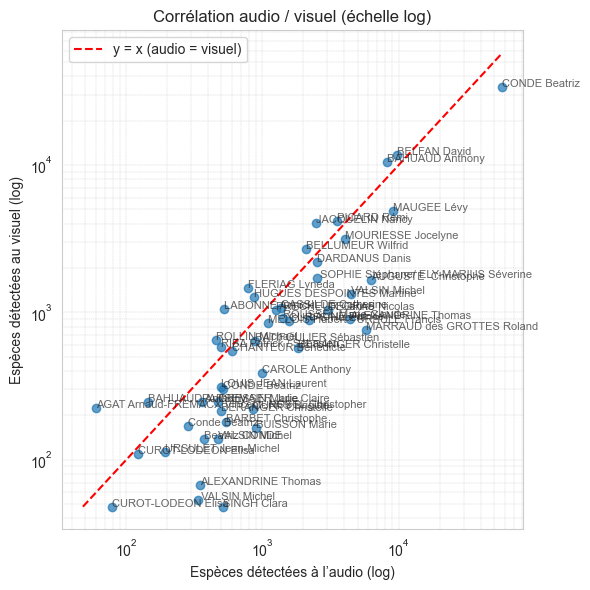

In [217]:
df_sum = df_full.groupby('observer')[['auditory_total', 'visual__no_flight_total']].sum().reset_index()

# Supposons que df_sum existe déjà
x = df_sum['auditory_total']
y = df_sum['visual__no_flight_total']

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.7)

# Ligne de référence à 45°
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x (audio = visuel)')

for i, row in df_sum.iterrows():
    plt.text(row['auditory_total'], row['visual__no_flight_total'], row['observer'], fontsize=8, alpha=0.7)

# Échelles log
plt.xscale('log')
plt.yscale('log')

plt.xlabel("Espèces détectées à l’audio (log)")
plt.ylabel("Espèces détectées au visuel (log)")
plt.title("Corrélation audio / visuel (échelle log)")
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.3)
plt.tight_layout()
plt.show()




In [206]:
df_sum['log_ratio'] = np.log10(df_sum['auditory_total'] / df_sum['visual__no_flight_total'])
print(df_sum['log_ratio'].describe())

from scipy.stats import ttest_1samp
t_stat, p_val = ttest_1samp(df_sum['log_ratio'], 0)
print(f"T = {t_stat:.3f}, p = {p_val:.3e}")


count    49.000000
mean      0.226919
std       0.336378
min      -0.572097
25%       0.038850
50%       0.210853
75%       0.466554
max       1.031408
Name: log_ratio, dtype: float64
T = 4.722, p = 2.062e-05


## 1bis.2 

## 1bis.3 

# 2. Multi-year indicators trends

L'effort d'échantillognage n'est pas égal pour tous les transects => effort non égal pour l'observation des espèces => l'abondance ne peut être fiable 

Nous avons calculé des indices de rareté spatiale basés sur la prévalence des espèces dans les sites d'échantillonnage. Une espèce est considérée comme rare si elle occupe une faible proportion des points de relevé, reflétant une distribution géographique restreinte à l'échelle de l'étude.

## 2.1 Selection of top-3 informative biodiversity indicators

In [228]:
def normalize_safe(x):
        if x.max() == x.min():
                return pd.Series(0.5, index=x.index)
        return (x - x.min()) / (x.max() - x.min())

In [237]:
# Sélectionner les colonnes pertinentes
cols_bio = ['transect', 'point', 'year', 'species']
df_bio = df_full[cols_bio].copy()

# Ajouter le comptage et filtrer les observations valides
df_bio['count'] = df_full['auditory_visual_with_flight_total'].fillna(0)
df_bio = df_bio[df_bio['count'] > 0]

### 2.1.0 Prévalence
- Mesure directe de la distribution spatiale
- Informations locales aux espèces 
- N'est pas une mesure globale de la diversité

### 2.1.1 Richesse spécifique 
- Indicateur intuitif, c'est tout simplement le nombre d'espèces
- Ignore totalement les abondances : une espèce en voie d'extinction vaut un eespèce abondante 

### 2.1.2 Détection des extinctions locales
- Identifie les espèces potentiellement disparues
-Directement actionnable (quelles espèces protéger en priorité)
- Sensible à la fréquence d'échantillonnage
- Ne distingue pas extinction réelle vs détectabilité nulle

### 2.1.3 Nombres de Hill
- Permet de choisir la sensibilité souhaitée aux espèces rares/abondantes
- Interprétable comme "nombre d'espèces également abondante"
- Ne capture pas la rareté géographique

### 2.1.4 Rarity-Weighted-Richness
- Les espèces rares contribues plus que les plus abondantes 
- Prend en considération la rareté et la richesse
- Capture la qualité de la biodiversité en plus de la quantité d'espèces

### 2.1.5 Composite Biodiversity Index 
Combine l'indice de Shannon et RWR.
- Flexible et vision holistique de la biodiversité
- Utile pour les décisions  multi-critères
- Choix de lambda pseudo-arbitraire

## 2.2 Computation of diffrent measures for each indicator form 2014 to 2025

### 2.2.0 Prévalence


In [253]:
# === 1. RARETÉ PAR ANNÉE (avec espèces absentes = prévalence 0) ===
rarete_annuelle = []

all_species = df_bio['species'].unique()

for year in df_bio['year'].unique():
    df_year = df_bio[df_bio['year'] == year]
    
    n_points_year = df_year['point'].nunique()
    
    prev_year = df_year.groupby('species')['point'].nunique() / n_points_year
    
    for species in all_species:
        if species in prev_year.index:
            prevalence = prev_year[species]
        else:
            prevalence = 0.0  # Espèce absente cette année
        
        rarete_annuelle.append({
            'year': year,
            'species': species,
            'prevalence': prevalence
        })

df_rarete = pd.DataFrame(rarete_annuelle)

### 2.2.1 Richesse spécifique 

In [ ]:
# Compter le nombre d'espèces UNIQUES par transect et par année
richesse = (
    df_bio.groupby(['transect', 'year'])['species']
    .nunique()
    .reset_index()
    .rename(columns={'species': 'nb_especes'})
)
n_species = df_bio.groupby('year')['species'].nunique()


print(richesse)
print(n_species)

           transect  year  nb_especes
0    anse couleuvre  2014          19
1    anse couleuvre  2015          18
2    anse couleuvre  2016          23
3    anse couleuvre  2017          17
4    anse couleuvre  2018          16
..              ...   ...         ...
718         verrier  2021          20
719         verrier  2022          24
720         verrier  2023          18
721         verrier  2024          24
722         verrier  2025          21

[723 rows x 3 columns]
year
2014    60
2015    65
2016    67
2017    64
2018    65
2019    65
2020    66
2021    65
2022    63
2023    62
2024    66
2025    70
Name: species, dtype: int64


### 2.2.2 Détection des extinctions locales

In [ ]:
# Première et dernière année d'observation par espèce
first_seen = df_bio.groupby('species')['year'].min()
last_seen = df_bio.groupby('species')['year'].max()
max_year = df_bio['year'].max()

# Espèces potentiellement éteintes (pas vues depuis 3+ ans)
seuil_extinction = 3
extinctions = last_seen[last_seen < (max_year - seuil_extinction)]

df_extinctions = pd.DataFrame({
    'species': extinctions.index,
    'first_year': first_seen[extinctions.index].values,
    'last_year': extinctions.values,
    'years_absent': max_year - extinctions.values
}).sort_values('last_year')

### 2.2.3 Nombres de Hill

In [233]:
from scipy.stats import entropy

def hill_number(counts, q):
    """Calcul des nombres de Hill"""
    counts = np.array(counts)
    counts = counts[counts > 0]  # Enlever les zéros
    p = counts / counts.sum()
    
    if q == 1:
        return np.exp(entropy(p))  # Shannon
    elif q == 0:
        return len(counts)  # Richesse
    else:
        return (np.sum(p ** q)) ** (1 / (1 - q))  # Hill général

# Calculer pour chaque année
hill_results = []
for year in df_bio['year'].unique():
    df_year = df_bio[df_bio['year'] == year]
    species_counts = df_year.groupby('species')['count'].sum()
    
    hill_results.append({
        'year': year,
        'richness_q0': hill_number(species_counts, q=0),
        'shannon_q1': hill_number(species_counts, q=1),
        'simpson_q2': hill_number(species_counts, q=2)
    })

df_hill = pd.DataFrame(hill_results).sort_values('year')

### 2.2.4.a Classic RWR 


In [ ]:
def calculate_rwr_with_k(df_bio, k_value):
    """Calcule le RWR avec un k donné"""
    all_species = df_bio['species'].unique()
    
    # 1. Calculer les prévalences annuelles
    rarete = []
    for year in df_bio['year'].unique():
        df_year = df_bio[df_bio['year'] == year]
        n_points = df_year['point'].nunique()
        prev = df_year.groupby('species')['point'].nunique() / n_points
        
        for species in all_species:
            rarete.append({
                'year': year,
                'species': species,
                'prevalence': prev.get(species, 0.0)
            })
    
    df_rarete = pd.DataFrame(rarete)
    
    # 2. Calculer les poids (avec k variable)
    df_active = df_rarete[df_rarete['prevalence'] > 0].copy()
    
    for year in df_active['year'].unique():
        mask = df_active['year'] == year
        df_active.loc[mask, 'weight'] = 1 / (df_active.loc[mask, 'prevalence'] ** k_value + 1e-6)
    
    #2bis. Normaliser les poids par année
    df_active['weight'] = 1 / (df_active['prevalence'] ** k_value + 1e-6)
    df_active['weight'] = df_active['weight'] / df_active['weight'].sum()

    # 3. Calculer RWR par année (UNE FOIS PAR ESPÈCE)
    rwr = (
        df_active.groupby('year')['weight']
        .sum()
        .reset_index()
        .rename(columns={'weight': 'RWR'})
    )

    
    return rwr

# Tester plusieurs valeurs
k_tests = [0.5, 1.0, 1.5, 2.0]
rwr_comparison = pd.DataFrame({'year': df_bio['year'].unique()})

for k in k_tests:
    rwr = calculate_rwr_with_k(df_bio, k)
    rwr_comparison = rwr_comparison.merge(
        rwr.rename(columns={'RWR': f'RWR_k{k}'}),
        on='year',
        how='left'
    )

print(rwr_comparison)

    year  RWR_k0.5  RWR_k1.0  RWR_k1.5  RWR_k2.0
0   2014  0.083769  0.091670  0.098271  0.102529
1   2015  0.085736  0.087643  0.088705  0.089070
2   2016  0.087530  0.088444  0.088082  0.086767
3   2017  0.083259  0.083495  0.082257  0.080055
4   2018  0.081560  0.079184  0.077512  0.076873
5   2019  0.083541  0.082972  0.082037  0.081142
6   2020  0.080048  0.074381  0.070295  0.068429
7   2021  0.082806  0.084123  0.087107  0.090322
8   2022  0.076049  0.070375  0.065797  0.062975
9   2023  0.075792  0.072995  0.072396  0.073300
10  2024  0.084886  0.084494  0.083608  0.082569
11  2025  0.095025  0.100224  0.103935  0.105969


### 2.2.4.b RWR avec bootstrap et normalisé par le nombre d'espèces 
Les années présentant un effort d’échantillonnage plus important détectent mécaniquement davantage d’espèces, y compris les plus rares, ce qui peut conduire à une surestimation du RWR.
- L’application d’un bootstrap permet de pallier en partie ce biais : l’indicateur est recalculé à partir de sous-échantillons de taille égale (nombre de points identique par année), répétés de nombreuses fois. Cette procédure homogénéise l’effort d’échantillonnage et fournit une estimation moyenne du RWR accompagnée de son incertitude.
- La normalisation par le nombre d’espèces observées permet ensuite de comparer les valeurs entre années ou régions, indépendamment des différences de richesse spécifique.
Ainsi, un RWR normalisé élevé traduit une communauté composée d’espèces plus rares ou à répartition plus restreinte, tandis qu’un RWR normalisé faible indique une dominance d’espèces plus communes ou plus largement réparties.


In [ ]:
def calculate_rwr_with_k_bootstrap(df_bio, k_value, n_boot=200, random_state=42):
    """Calcule le RWR avec rééchantillonnage bootstrap pour homogénéiser l'effort d'échantillonnage."""
    rng = np.random.default_rng(random_state)

    # Nombre minimal de points échantillonnés parmi les années
    min_points = (
        df_bio.groupby('year')['point']
        .nunique()
        .min()
    )

    all_years = sorted(df_bio['year'].unique())
    all_species = df_bio['species'].unique()
    boot_results = []

    for b in range(n_boot):
        rwr_boot = []

        for year in all_years:
            df_year = df_bio[df_bio['year'] == year]
            all_points = df_year['point'].unique()

            # Tirage aléatoire sans remise de min_points
            if len(all_points) < min_points:
                continue  # sauter si trop peu de points (cas rare)
            sampled_points = rng.choice(all_points, min_points, replace=False)
            df_sample = df_year[df_year['point'].isin(sampled_points)]

            # Calcul des prévalences pour l'échantillon
            n_points = df_sample['point'].nunique()
            prev = df_sample.groupby('species')['point'].nunique() / n_points

            # Calcul des poids de rareté
            df_r = pd.DataFrame({
                'species': all_species,
                'prevalence': [prev.get(sp, 0.0) for sp in all_species]
            })
            df_r = df_r[df_r['prevalence'] > 0]
            df_r['weight'] = 1 / (df_r['prevalence'] ** k_value + 1e-6)

            # RWR total (somme)
            rwr_value = df_r['weight'].sum() / len(df_r)
            rwr_boot.append({'year': year, 'RWR': rwr_value})

        boot_results.append(pd.DataFrame(rwr_boot))

    # Agréger les résultats bootstrap
    df_boot_all = pd.concat(boot_results)
    rwr_summary = (
        df_boot_all.groupby('year')['RWR']
        .agg(
            RWR_mean='mean',
            RWR_sd='std',
            RWR_q2_5=lambda x: np.percentile(x, 2.5),
            RWR_q97_5=lambda x: np.percentile(x, 97.5)
        )
        .reset_index()
    )


    return rwr_summary


In [249]:
k_tests = [0.5, 1.0, 1.5, 2.0]
rwr_boot_comparison = pd.DataFrame({'year': sorted(df_bio['year'].unique())})

for k in k_tests:
    rwr_summary = calculate_rwr_with_k_bootstrap(df_bio, k, n_boot=500)
    rwr_boot_comparison = rwr_boot_comparison.merge(
        rwr_summary[['year', 'RWR_mean']].rename(columns={'RWR_mean': f'RWR_k{k}'}),
        on='year',
        how='left'
    )

print(rwr_boot_comparison)


    year  RWR_k0.5  RWR_k1.0  RWR_k1.5   RWR_k2.0
0   2014  1.603097  3.246142  7.974989  22.060730
1   2015  1.514518  2.864817  6.644950  17.690740
2   2016  1.500054  2.804710  6.401294  16.718830
3   2017  1.493750  2.771871  6.258178  16.148517
4   2018  1.440750  2.588324  5.806498  15.268140
5   2019  1.475747  2.712133  6.145436  16.116017
6   2020  1.392627  2.394467  5.186042  13.385195
7   2021  1.462769  2.749738  6.525230  17.939357
8   2022  1.386047  2.373381  5.085411  12.904909
9   2023  1.403653  2.501457  5.685640  15.262966
10  2024  1.476790  2.720042  6.168241  16.150983
11  2025  1.558710  3.042044  7.229681  19.543720


In [254]:
# Calculer la corrélation entre k et les tendances observées
for k in k_tests:
    correlation = np.corrcoef(
        rwr_comparison['year'], 
        rwr_comparison[f'RWR_k{k}']
    )[0, 1]
    print(f"k={k} → Tendance temporelle : {correlation:.3f}")

k=0.5 → Tendance temporelle : -0.004
k=1.0 → Tendance temporelle : -0.153
k=1.5 → Tendance temporelle : -0.181
k=2.0 → Tendance temporelle : -0.172


### 2.2.5 Composite Biodiversity Index 

In [257]:
def calculate_cbi_grid(df_bio, rwr_summary, lambda_value, n_boot=500):
    """Calcule le CBI pour un couple (k, λ) avec RWR bootstrapé et normalisé."""
    
    # 1. Calculer Shannon (Hill q=1)
    hill_results = []
    for year in df_bio['year'].unique():
        df_year = df_bio[df_bio['year'] == year]
        counts = df_year.groupby('species')['count'].sum()
        p = counts / counts.sum()
        shannon = np.exp(-np.sum(p * np.log(p + 1e-10)))  # Hill number q=1
        hill_results.append({'year': year, 'shannon': shannon})
    df_shannon = pd.DataFrame(hill_results)

    # 2. Calculer RWR bootstrapé et normalisé
    rwr = rwr_summary
    rwr = rwr.rename(columns={'RWR_mean': 'RWR'})  # simplification

    # 3. Fusion et normalisation (robuste)
    df_combined = df_shannon.merge(rwr, on='year', how='inner')

    shannon_norm = (df_combined['shannon'] - df_combined['shannon'].min()) / \
                    (df_combined['shannon'].max() - df_combined['shannon'].min() + 1e-10)

    rwr_norm = (df_combined['RWR'] - df_combined['RWR'].min()) / \
                (df_combined['RWR'].max() - df_combined['RWR'].min() + 1e-10)

    # 4. Calcul du CBI selon λ
    df_combined['CBI'] = lambda_value * shannon_norm + (1 - lambda_value) * rwr_norm

    return df_combined

In [259]:
k_grid = [0.5, 1.0, 2.0]
lambda_grid = [0.3, 0.5, 0.7, 0.9]

results_grid = []

for k in k_grid:
    for lam in lambda_grid:
        cbi_data = calculate_cbi_grid(df_bio, rwr_summary, lam, n_boot=300)
        cbi_range = cbi_data['CBI'].max() - cbi_data['CBI'].min()
        cbi_std = cbi_data['CBI'].std()
        results_grid.append({
            'k': k,
            'lambda': lam,
            'CBI_range': cbi_range,
            'CBI_std': cbi_std
        })

df_grid = pd.DataFrame(results_grid)
print(df_grid)

      k  lambda  CBI_range   CBI_std
0   0.5     0.3   0.596069  0.182512
1   0.5     0.5   0.573499  0.157700
2   0.5     0.7   0.617528  0.179461
3   0.5     0.9   0.872509  0.235205
4   1.0     0.3   0.596069  0.182512
5   1.0     0.5   0.573499  0.157700
6   1.0     0.7   0.617528  0.179461
7   1.0     0.9   0.872509  0.235205
8   2.0     0.3   0.596069  0.182512
9   2.0     0.5   0.573499  0.157700
10  2.0     0.7   0.617528  0.179461
11  2.0     0.9   0.872509  0.235205


## 2.3 Quantification and interpretation of temporal trends 

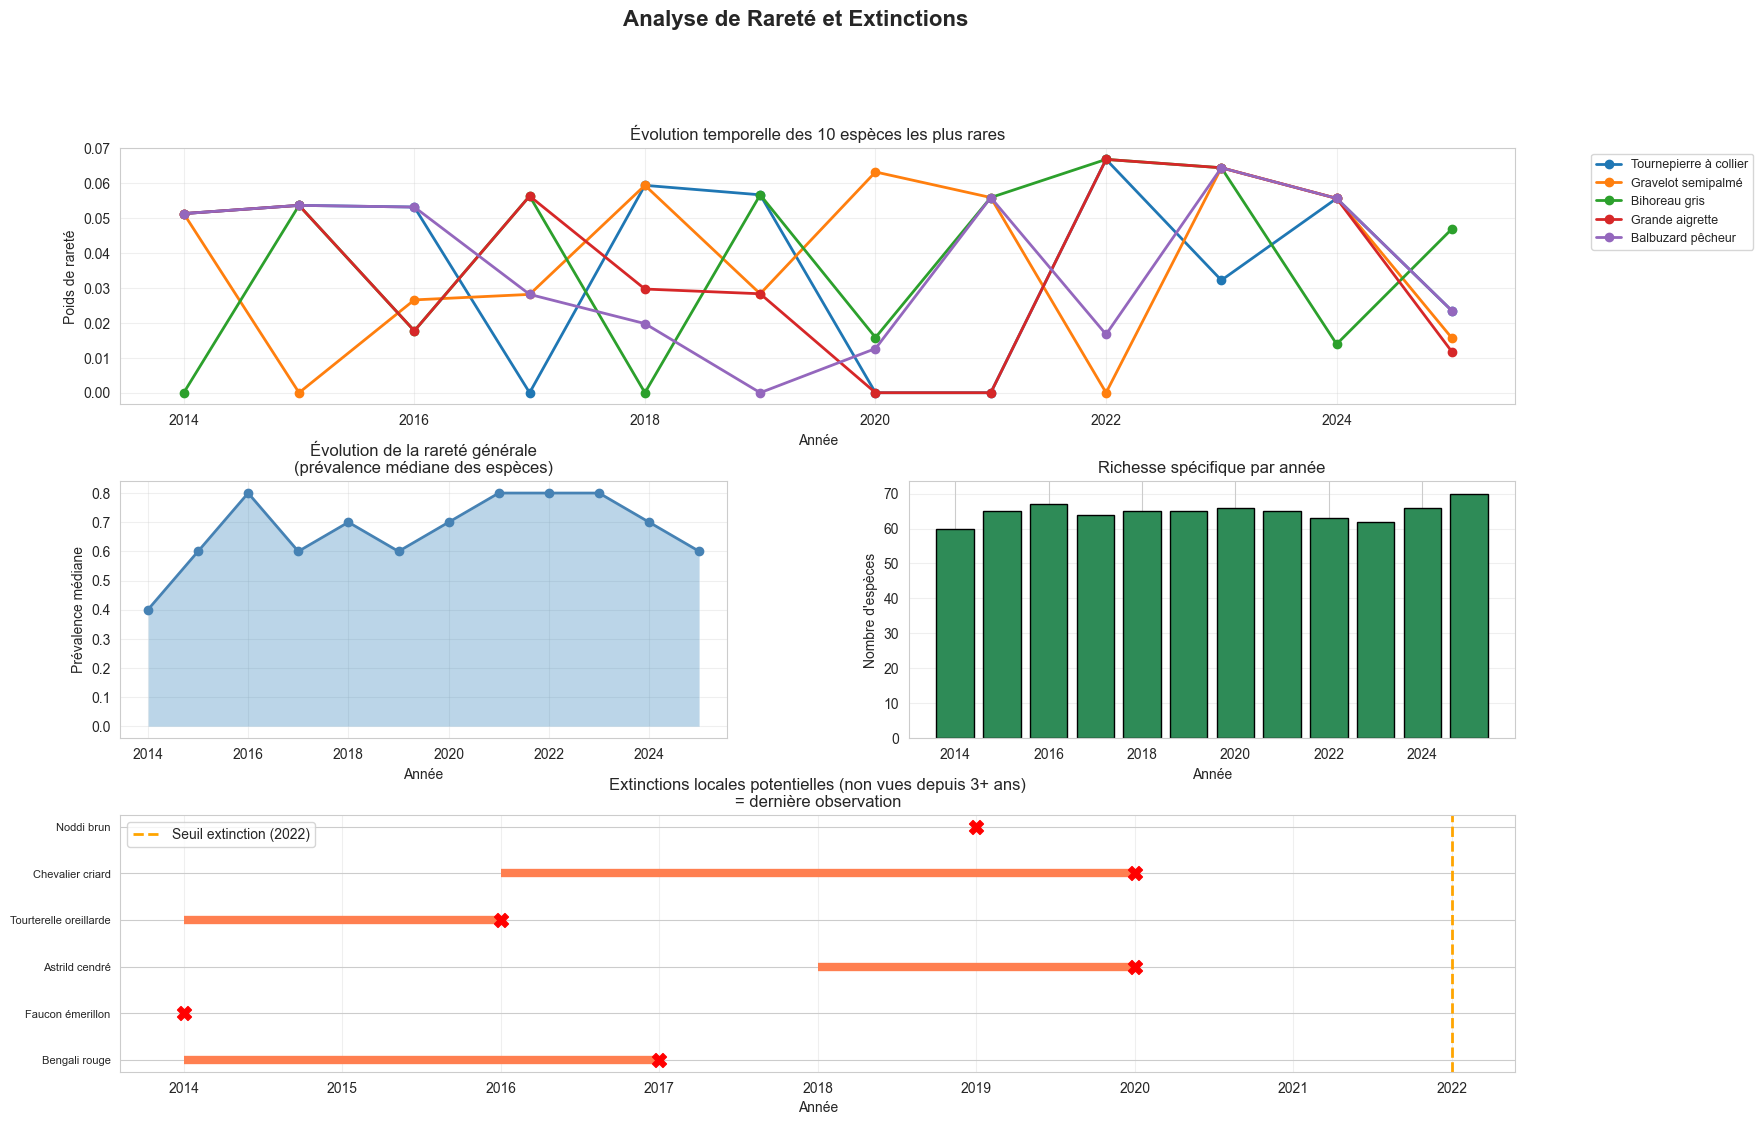


STATISTIQUES DE RARETÉ
Nombre total d'espèces observées : 81
Période : 2014 → 2025

Prévalence médiane par année :
year
2014    0.4
2015    0.6
2016    0.8
2017    0.6
2018    0.7
2019    0.6
2020    0.7
2021    0.8
2022    0.8
2023    0.8
2024    0.7
2025    0.6
Name: prevalence, dtype: float64

EXTINCTIONS POTENTIELLES
Nombre d'espèces non vues depuis 3+ ans : 6

Top 10 disparitions les plus anciennes :
               species  first_year  last_year  years_absent
         Bengali rouge        2014       2014            11
      Faucon émerillon        2014       2016             9
        Astrild cendré        2014       2017             8
Tourterelle oreillarde        2019       2019             6
      Chevalier criard        2018       2020             5
            Noddi brun        2016       2020             5


In [ ]:


# === GRAPHIQUES ===
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)


# Top 10 espèces les plus rares par année
ax1 = fig.add_subplot(gs[0, :])

top_species = df_rarete.groupby('species')['weight'].mean().nlargest(5).index

for species in top_species:
    data = df_rarete[df_rarete['species'] == species].sort_values('year')
    ax1.plot(data['year'], data['weight'], marker='o', label=species[:25], linewidth=2)

ax1.set_xlabel('Année')
ax1.set_ylabel('Poids de rareté')
ax1.set_title('Évolution temporelle des 10 espèces les plus rares')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax1.grid(alpha=0.3)

# Évolution de la prévalence médiane
ax2 = fig.add_subplot(gs[1, 0])
prev_median = df_rarete.groupby('year')['prevalence'].median()
ax2.plot(prev_median.index, prev_median.values, marker='o', linewidth=2, color='steelblue')
ax2.fill_between(prev_median.index, prev_median.values, alpha=0.3)
ax2.set_xlabel('Année')
ax2.set_ylabel('Prévalence médiane')
ax2.set_title('Évolution de la rareté générale\n(prévalence médiane des espèces)')
ax2.grid(alpha=0.3)

# Nombre d'espèces observées par année
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(n_species.index, n_species.values, color='seagreen', edgecolor='black')
ax3.set_xlabel('Année')
ax3.set_ylabel('Nombre d\'espèces')
ax3.set_title('Richesse spécifique par année')
ax3.grid(axis='y', alpha=0.3)

# Timeline des extinctions
ax4 = fig.add_subplot(gs[2, :])
if len(df_extinctions) > 0:
    top_extinctions = df_extinctions.nlargest(20, 'years_absent')
    for idx, row in top_extinctions.iterrows():
        ax4.plot([row['first_year'], row['last_year']], [idx, idx], 
                linewidth=6, solid_capstyle='butt', color='coral')
        ax4.scatter(row['last_year'], idx, color='red', s=100, zorder=3, marker='X')
    ax4.set_yticks(range(len(top_extinctions)))
    ax4.set_yticklabels([sp[:30] for sp in top_extinctions['species']], fontsize=8)
    ax4.set_xlabel('Année')
    ax4.set_title(f'Extinctions locales potentielles (non vues depuis {seuil_extinction}+ ans)\n= dernière observation')
    ax4.axvline(max_year - seuil_extinction, color='orange', linestyle='--', 
                label=f'Seuil extinction ({max_year - seuil_extinction})', linewidth=2)
    ax4.legend()
    ax4.grid(axis='x', alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Aucune extinction détectée', ha='center', va='center', fontsize=14)
    ax4.set_title('Extinctions locales')

plt.suptitle('Analyse de Rareté et Extinctions', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# === STATISTIQUES ===
print(f"\nSTATISTIQUES DE RARETÉ")
print(f"{'='*50}")
print(f"Nombre total d'espèces observées : {df_bio['species'].nunique()}")
print(f"Période : {df_bio['year'].min()} → {df_bio['year'].max()}")
print(f"\nPrévalence médiane par année :")
print(prev_median)

print(f"\nEXTINCTIONS POTENTIELLES")
print(f"{'='*50}")
print(f"Nombre d'espèces non vues depuis {seuil_extinction}+ ans : {len(extinctions)}")
if len(df_extinctions) > 0:
    print(f"\nTop 10 disparitions les plus anciennes :")
    print(df_extinctions.head(10).to_string(index=False))

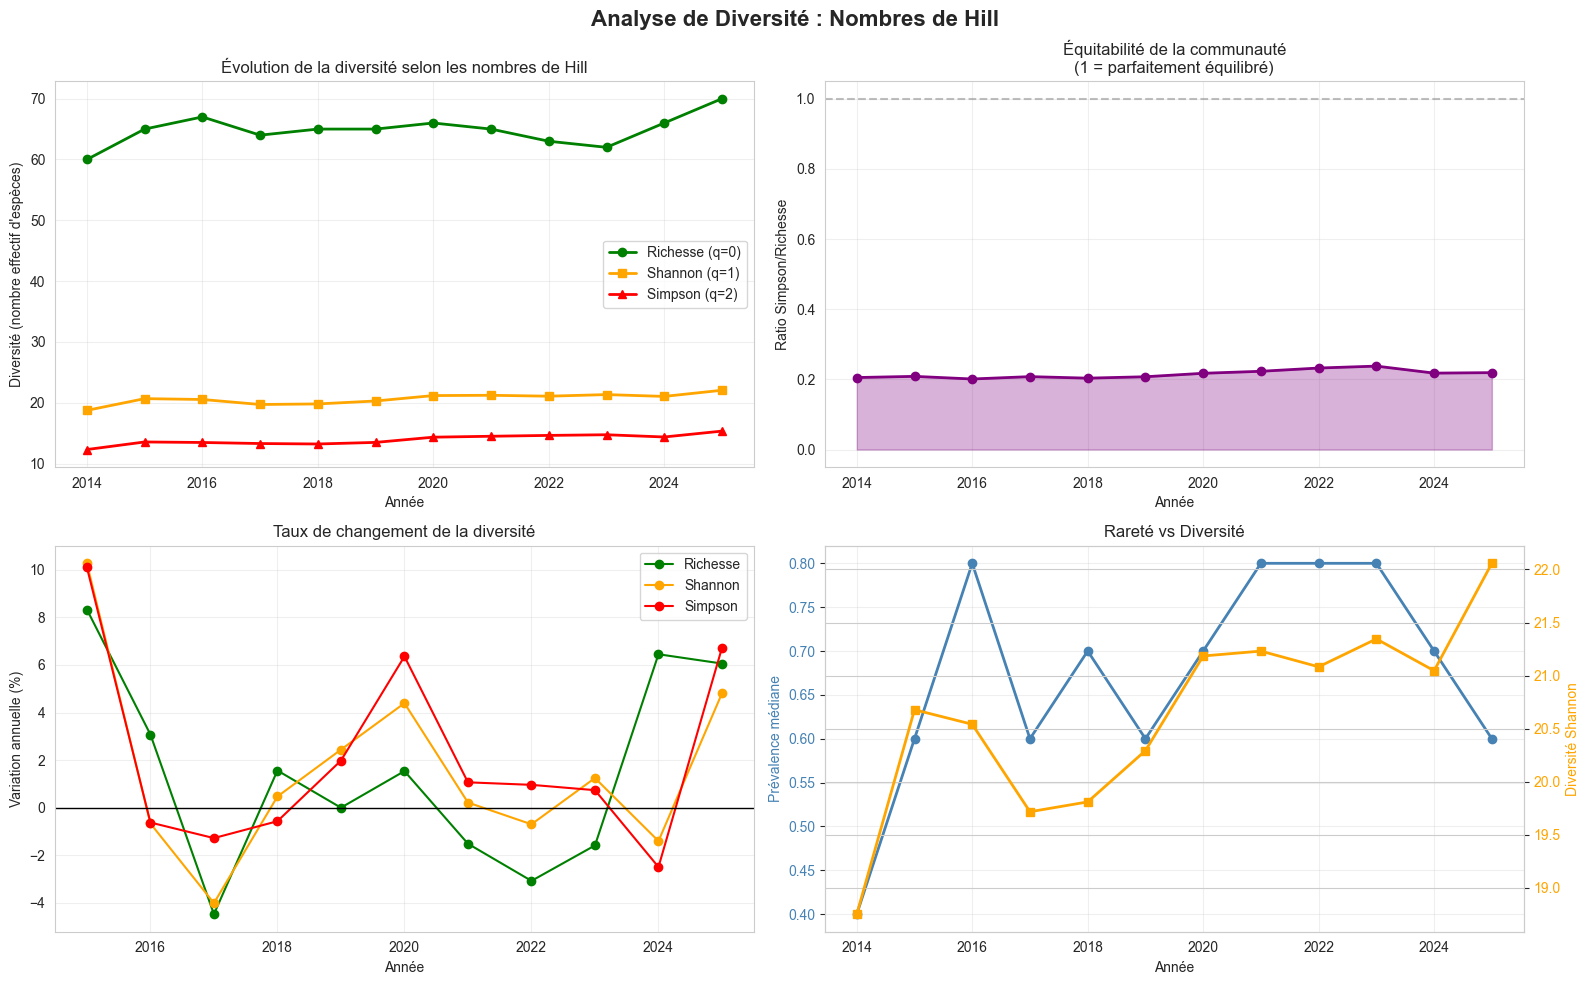


DIVERSITÉ (Nombres de Hill)
 year  richness_q0  shannon_q1  simpson_q2
 2014           60   18.751359   12.311638
 2015           65   20.678152   13.555765
 2016           67   20.540939   13.471237
 2017           64   19.716665   13.298914
 2018           65   19.809445   13.223279
 2019           65   20.292825   13.485039
 2020           66   21.184738   14.342749
 2021           65   21.230735   14.495717
 2022           63   21.082536   14.634968
 2023           62   21.345479   14.742739
 2024           66   21.045857   14.375019
 2025           70   22.058072   15.341566

TENDANCES
Richesse     : +0.28 espèces/an Hausse (R²=0.16, p=0.197)
Shannon      : +0.20 espèces/an Hausse (R²=0.66, p=0.001)
Simpson      : +0.21 espèces/an Hausse (R²=0.82, p=0.000)


In [ ]:
# === GRAPHIQUES ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Évolution des 3 indices de Hill
ax1 = axes[0, 0]
ax1.plot(df_hill['year'], df_hill['richness_q0'], marker='o', linewidth=2, 
        label='Richesse (q=0)', color='green')
ax1.plot(df_hill['year'], df_hill['shannon_q1'], marker='s', linewidth=2, 
        label='Shannon (q=1)', color='orange')
ax1.plot(df_hill['year'], df_hill['simpson_q2'], marker='^', linewidth=2, 
        label='Simpson (q=2)', color='red')
ax1.set_xlabel('Année')
ax1.set_ylabel('Diversité (nombre effectif d\'espèces)')
ax1.set_title('Évolution de la diversité selon les nombres de Hill')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Ratio Simpson/Richesse (équitabilité)
ax2 = axes[0, 1]
equitability = df_hill['simpson_q2'] / df_hill['richness_q0']
ax2.plot(df_hill['year'], equitability, marker='o', linewidth=2, color='purple')
ax2.fill_between(df_hill['year'], equitability, alpha=0.3, color='purple')
ax2.set_xlabel('Année')
ax2.set_ylabel('Ratio Simpson/Richesse')
ax2.set_title('Équitabilité de la communauté\n(1 = parfaitement équilibré)')
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax2.grid(alpha=0.3)

# 3. Taux de changement annuel
ax3 = axes[1, 0]
for col, label, color in [('richness_q0', 'Richesse', 'green'), 
                        ('shannon_q1', 'Shannon', 'orange'),
                        ('simpson_q2', 'Simpson', 'red')]:
    changes = df_hill[col].pct_change() * 100
    ax3.plot(df_hill['year'][1:], changes[1:], marker='o', label=label, color=color)

ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_xlabel('Année')
ax3.set_ylabel('Variation annuelle (%)')
ax3.set_title('Taux de changement de la diversité')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Comparaison Prévalence médiane vs Shannon
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()

# Prévalence médiane (axe gauche)
prev_med = df_rarete.groupby('year')['prevalence'].median()
ax4.plot(prev_med.index, prev_med.values, marker='o', linewidth=2, 
        color='steelblue', label='Prévalence médiane')
ax4.set_xlabel('Année')
ax4.set_ylabel('Prévalence médiane', color='steelblue')
ax4.tick_params(axis='y', labelcolor='steelblue')

# Shannon (axe droit)
ax4_twin.plot(df_hill['year'], df_hill['shannon_q1'], marker='s', linewidth=2, 
            color='orange', label='Shannon (q=1)')
ax4_twin.set_ylabel('Diversité Shannon', color='orange')
ax4_twin.tick_params(axis='y', labelcolor='orange')

ax4.set_title('Rareté vs Diversité')
ax4.grid(alpha=0.3)

plt.suptitle('Analyse de Diversité : Nombres de Hill', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# === STATISTIQUES ===
print(f"\nDIVERSITÉ (Nombres de Hill)")
print(f"{'='*60}")
print(df_hill.to_string(index=False))

print(f"\nTENDANCES")
print(f"{'='*60}")
for col, label in [('richness_q0', 'Richesse'), 
                    ('shannon_q1', 'Shannon'), 
                    ('simpson_q2', 'Simpson')]:
    from scipy.stats import linregress
    slope, _, r, p, _ = linregress(df_hill['year'], df_hill[col])
    trend = "Hausse" if slope > 0 else "Baisse"
    print(f"{label:12} : {slope:+.2f} espèces/an {trend} (R²={r**2:.2f}, p={p:.3f})")

In [161]:
print(f"\nINTERPRÉTATION DES RÉSULTATS")
print(f"{'='*60}")

# Comparer début et fin
premiere_annee = df_hill.iloc[0]
derniere_annee = df_hill.iloc[-1]

ratio_simpson_debut = premiere_annee['simpson_q2'] / premiere_annee['richness_q0']
ratio_simpson_fin = derniere_annee['simpson_q2'] / derniere_annee['richness_q0']

#En pourcentage
var_richesse = ((derniere_annee['richness_q0'] / premiere_annee['richness_q0']) - 1) * 100
var_shannon = ((derniere_annee['shannon_q1'] / premiere_annee['shannon_q1']) - 1) * 100
var_simpson = ((derniere_annee['simpson_q2'] / premiere_annee['simpson_q2']) - 1) * 100

# Tendances
from scipy.stats import linregress
pente_richesse, _, r2_rich, p_rich, _ = linregress(df_hill['year'], df_hill['richness_q0'])
pente_shannon, _, r2_shan, p_shan, _ = linregress(df_hill['year'], df_hill['shannon_q1'])
pente_simpson, _, r2_simp, p_simp, _ = linregress(df_hill['year'], df_hill['simpson_q2'])

print(f"\n1. EVOLUTION TEMPORELLE ({int(premiere_annee['year'])} - {int(derniere_annee['year'])})")
print("-" * 60)

if pente_richesse > 0 and pente_shannon > 0 and pente_simpson > 0:
    print("Tendance générale : Augmentation de la biodiversité")
    print(f"\nRichesse spécifique  : {premiere_annee['richness_q0']:.0f} -> {derniere_annee['richness_q0']:.0f} espèces ({var_richesse:+.1f}%)")
    print(f"Diversité Shannon    : {premiere_annee['shannon_q1']:.1f} -> {derniere_annee['shannon_q1']:.1f} ({var_shannon:+.1f}%)")
    print(f"Diversité Simpson    : {premiere_annee['simpson_q2']:.1f} -> {derniere_annee['simpson_q2']:.1f} ({var_simpson:+.1f}%)")
    
elif pente_richesse < 0 and pente_shannon < 0 and pente_simpson < 0:
    print("Tendance générale : Déclin de la biodiversité")
    print(f"\nPerte de richesse    : {pente_richesse:.2f} espèces/an (p={p_rich:.3f})")
    print(f"Perte de diversité   : Shannon {pente_shannon:.2f}/an, Simpson {pente_simpson:.2f}/an")
    
else:
    print("Tendance générale : Evolution contrastée")
    print(f"\nRichesse : {var_richesse:+.1f}% | Shannon : {var_shannon:+.1f}% | Simpson : {var_simpson:+.1f}%")

print(f"\n2. STRUCTURE DE LA COMMUNAUTE")
print("-" * 60)

n_dominantes = int(derniere_annee['simpson_q2'])
n_totales = int(derniere_annee['richness_q0'])

print(f"Nombre d'espèces total        : {n_totales}")
print(f"Espèces dominantes effectives : ~{n_dominantes}")
print(f"Ratio dominantes/total        : {ratio_simpson_fin:.2f}")

if ratio_simpson_fin > 0.7:
    diagnostic = "Communauté équilibrée - Faible dominance"
elif ratio_simpson_fin > 0.5:
    diagnostic = "Communauté moyennement équilibrée"
elif ratio_simpson_fin > 0.3:
    diagnostic = "Dominance modérée - Structure typique"
else:
    diagnostic = "Dominance forte - Concentration sur quelques espèces"

print(f"\nDiagnostic : {diagnostic}")

# Evolution de l'équitabilité
delta_ratio = ratio_simpson_fin - ratio_simpson_debut
if abs(delta_ratio) < 0.05:
    tendance_equit = "stable"
elif delta_ratio > 0:
    tendance_equit = "en amélioration"
else:
    tendance_equit = "en dégradation"

print(f"Evolution de l'équitabilité : {tendance_equit} (delta = {delta_ratio:+.3f})")

print(f"\n3. SIGNIFICATIVITE STATISTIQUE")
print("-" * 60)
print(f"Richesse  : R² = {r2_rich**2:.2f}, p-value = {p_rich:.4e} {'(significatif)' if p_rich < 0.05 else '(non significatif)'}")
print(f"Shannon   : R² = {r2_shan**2:.2f}, p-value = {p_shan:.4e} {'(significatif)' if p_shan < 0.05 else '(non significatif)'}")
print(f"Simpson   : R² = {r2_simp**2:.2f}, p-value = {p_simp:.4e} {'(significatif)' if p_simp < 0.05 else '(non significatif)'}")


INTERPRÉTATION DES RÉSULTATS

1. EVOLUTION TEMPORELLE (2014 - 2025)
------------------------------------------------------------
Tendance générale : Augmentation de la biodiversité

Richesse spécifique  : 60 -> 70 espèces (+16.7%)
Diversité Shannon    : 18.8 -> 22.1 (+17.6%)
Diversité Simpson    : 12.3 -> 15.3 (+24.6%)

2. STRUCTURE DE LA COMMUNAUTE
------------------------------------------------------------
Nombre d'espèces total        : 70
Espèces dominantes effectives : ~15
Ratio dominantes/total        : 0.22

Diagnostic : Dominance forte - Concentration sur quelques espèces
Evolution de l'équitabilité : stable (delta = +0.014)

3. SIGNIFICATIVITE STATISTIQUE
------------------------------------------------------------
Richesse  : R² = 0.16, p-value = 1.9669e-01 (non significatif)
Shannon   : R² = 0.66, p-value = 1.4150e-03 (significatif)
Simpson   : R² = 0.82, p-value = 4.7598e-05 (significatif)


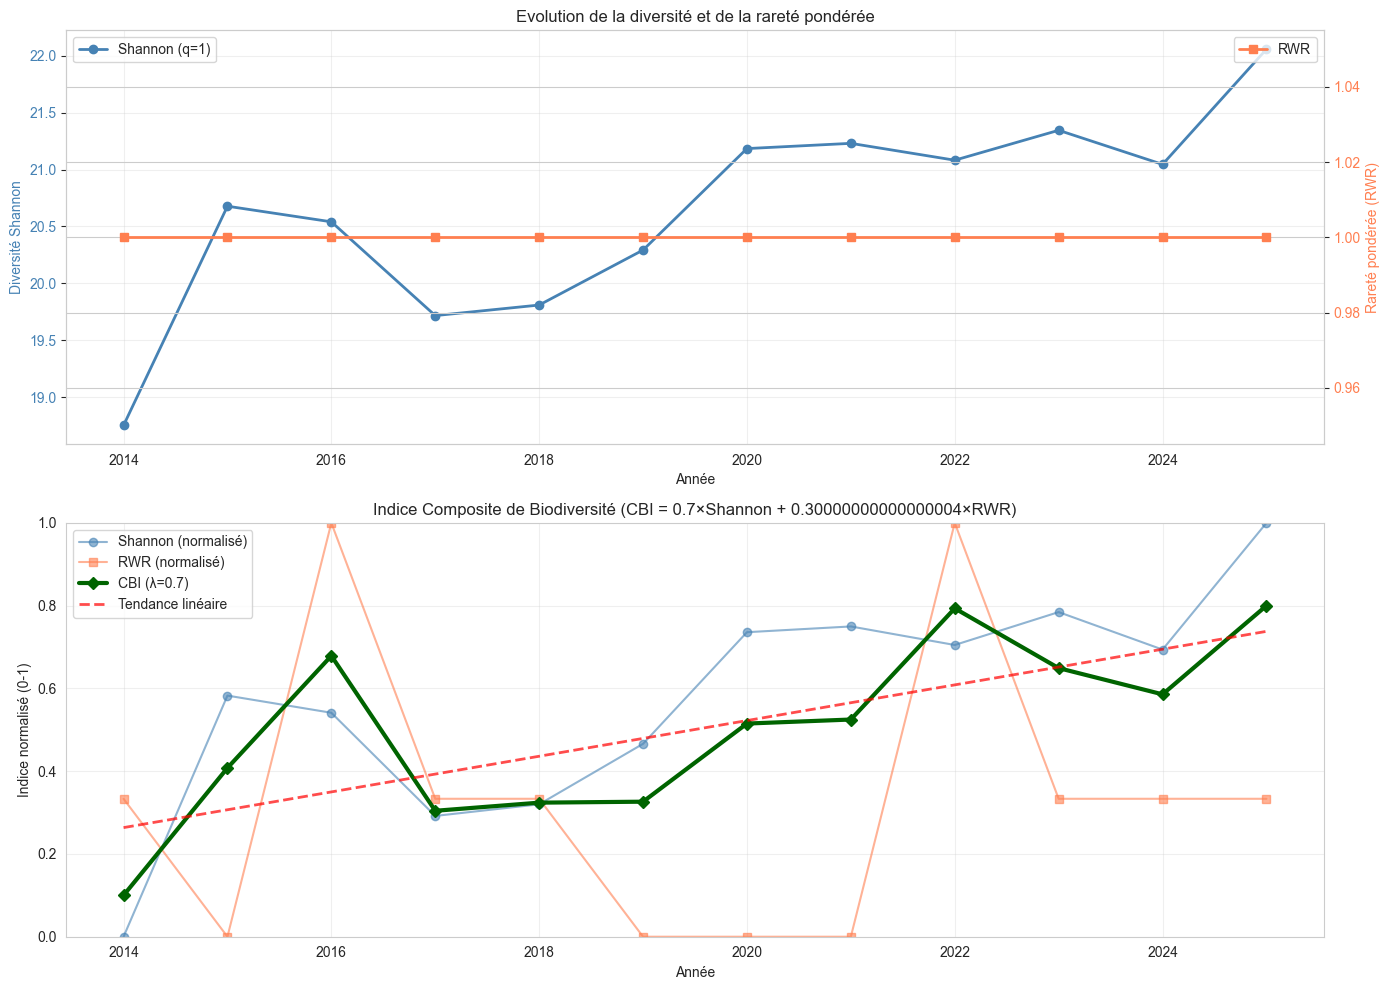

In [ ]:

# Graphiques
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Indices bruts
ax1 = axes[0]
ax1.plot(df_indices['year'], df_indices['shannon_q1'], 
        marker='o', linewidth=2, label='Shannon (q=1)', color='steelblue')
ax1.set_ylabel('Diversité Shannon', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(df_indices['year'], df_indices['RWR'], 
                marker='s', linewidth=2, label='RWR', color='coral')
ax1_twin.set_ylabel('Rareté pondérée (RWR)', color='coral')
ax1_twin.tick_params(axis='y', labelcolor='coral')

ax1.set_xlabel('Année')
ax1.set_title('Evolution de la diversité et de la rareté pondérée')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# Indice composite normalisé
ax2 = axes[1]
ax2.plot(df_indices['year'], df_indices['shannon_norm'], 
        marker='o', linewidth=1.5, label='Shannon (normalisé)', 
        color='steelblue', alpha=0.6)
ax2.plot(df_indices['year'], df_indices['rwr_norm'], 
        marker='s', linewidth=1.5, label='RWR (normalisé)', 
        color='coral', alpha=0.6)
ax2.plot(df_indices['year'], df_indices['CBI'], 
        marker='D', linewidth=3, label=f'CBI (λ={lambda_weight})', 
        color='darkgreen')

# Ajouter régression linéaire sur CBI
X_reg = df_indices['year'].values
y_reg = df_indices['CBI'].values
z = np.polyfit(X_reg, y_reg, 1)
p = np.poly1d(z)
ax2.plot(X_reg, p(X_reg), '--', color='red', linewidth=2, 
        alpha=0.7, label='Tendance linéaire')

ax2.set_xlabel('Année')
ax2.set_ylabel('Indice normalisé (0-1)')
ax2.set_title(f'Indice Composite de Biodiversité (CBI = {lambda_weight}×Shannon + {1-lambda_weight}×RWR)')
ax2.legend(loc='best')
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
for k in k_tests:
    plt.plot(rwr_boot_comparison['year'], rwr_boot_comparison[f'RWR_k{k}'], label=f'k={k}')
plt.xlabel('Year')
plt.ylabel('Mean RWR (bootstrap-adjusted)')
plt.title('RWR with bootstrapped sampling effort correction')
plt.legend()
plt.show()

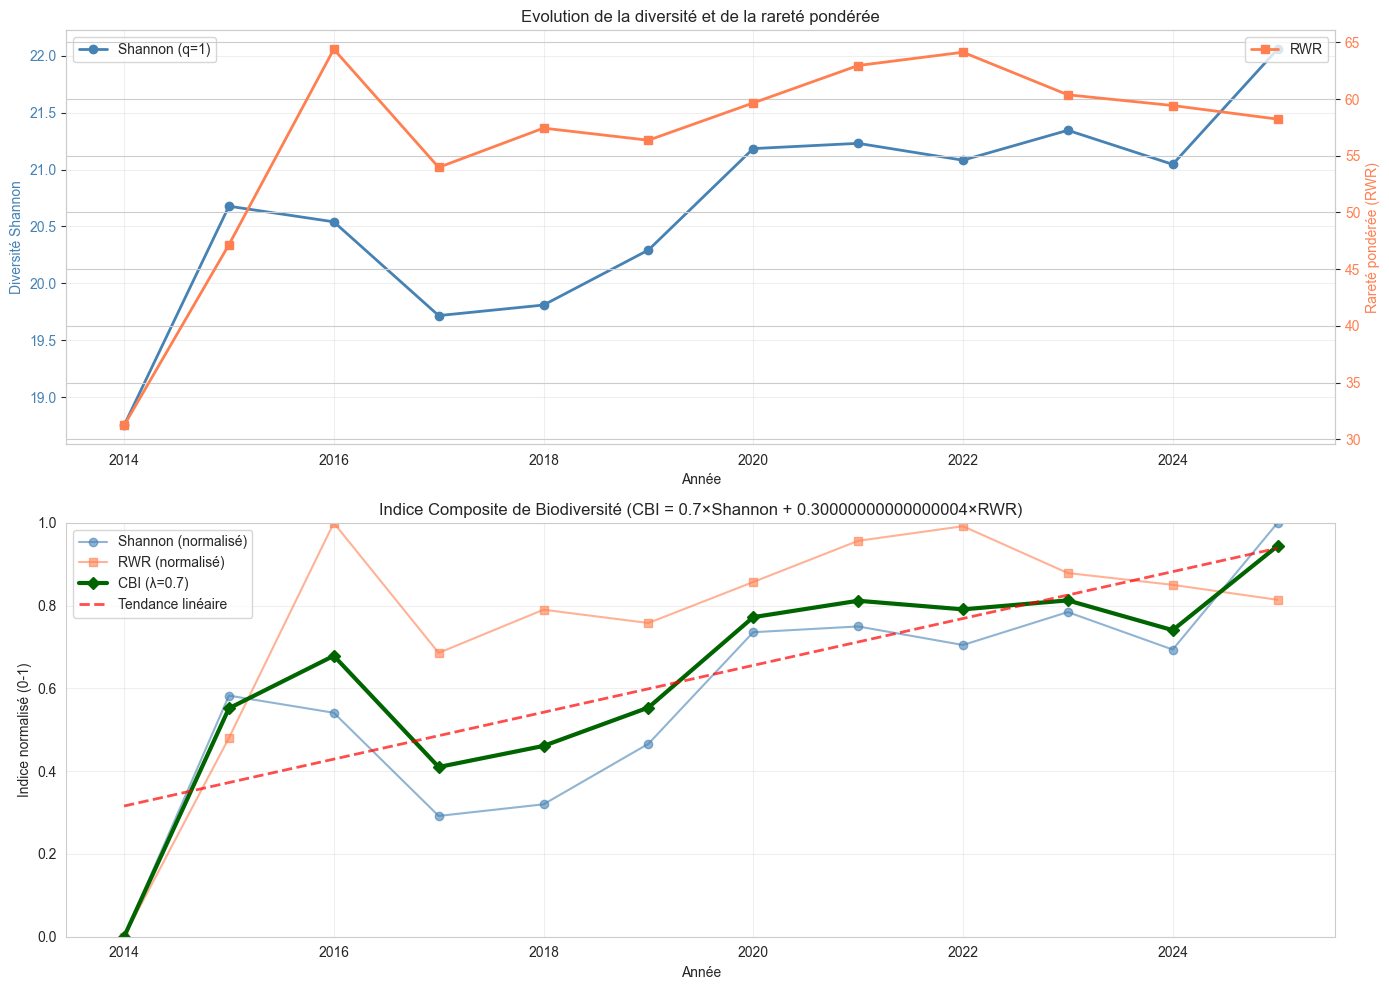

In [ ]:
## Graphiques
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Indices bruts
ax1 = axes[0]
ax1.plot(df_indices['year'], df_indices['shannon_q1'], 
        marker='o', linewidth=2, label='Shannon (q=1)', color='steelblue')
ax1.set_ylabel('Diversité Shannon', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(df_indices['year'], df_indices['RWR'], 
                marker='s', linewidth=2, label='RWR', color='coral')
ax1_twin.set_ylabel('Rareté pondérée (RWR)', color='coral')
ax1_twin.tick_params(axis='y', labelcolor='coral')

ax1.set_xlabel('Année')
ax1.set_title('Evolution de la diversité et de la rareté pondérée')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# Indice composite normalisé
ax2 = axes[1]
ax2.plot(df_indices['year'], df_indices['shannon_norm'], 
        marker='o', linewidth=1.5, label='Shannon (normalisé)', 
        color='steelblue', alpha=0.6)
ax2.plot(df_indices['year'], df_indices['rwr_norm'], 
        marker='s', linewidth=1.5, label='RWR (normalisé)', 
        color='coral', alpha=0.6)
ax2.plot(df_indices['year'], df_indices['CBI'], 
        marker='D', linewidth=3, label=f'CBI (λ={lambda_weight})', 
        color='darkgreen')

# Ajouter régression linéaire sur CBI
X_reg = df_indices['year'].values
y_reg = df_indices['CBI'].values
z = np.polyfit(X_reg, y_reg, 1)
p = np.poly1d(z)
ax2.plot(X_reg, p(X_reg), '--', color='red', linewidth=2, 
        alpha=0.7, label='Tendance linéaire')

ax2.set_xlabel('Année')
ax2.set_ylabel('Indice normalisé (0-1)')
ax2.set_title(f'Indice Composite de Biodiversité (CBI = {lambda_weight}×Shannon + {1-lambda_weight}×RWR)')
ax2.legend(loc='best')
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# 3.Species level evolution

## 3.1. Interesting subsets of birds

## 3.2 Analysis of species previously selected

## 3.3 Potential ecological reasons behind the previously observed patterns

# 4. Synthesis and recomendations

## 4.1 Main insights adn summaries

## 4.2 Actionnable recommendations

## 4.3 Reflect on limitations

Nombre de lignes dupliquées dans df_full : 3010
hello


In [ ]:
#montre les doublons et le nombre de lignes double dans df_full en prenant en considération toutes les colonnes
print("\n" + "="*60)
print("DOUBLONS DANS LE JEU DE DONNÉES")
print("="*60)
duplicates = df_full.duplicated()
num_duplicates = duplicates.sum()
print(f"Nombre de lignes dupliquées : {num_duplicates}")
if num_duplicates > 0:
    print("Exemples de lignes dupliquées :")
    print(df_full[duplicates].head())

In [ ]:
#output the number of duplicates for each scientist observer
print("\n" + "="*60)
print("DOUBLONS PAR OBSERVATEUR")
print("="*60)
duplicate_counts = df_full[duplicates].groupby('observer').size().reset_index(name='num_duplicates')
print(duplicate_counts.sort_values(by='num_duplicates', ascending=False))


DOUBLONS PAR OBSERVATEUR
                                 observer  num_duplicates
4                         BAHUAUD Anthony             924
31                            PICARD Rémi             626
14                          CONDE Beatriz             624
19                         DEGRAS Nicolas             203
13                     CASSILDE Catherine             155
36                          VALSIN Michel             155
28         MELOIS Hubert - URSULE Francis              71
0    SOPHIE Stéphane/ ELY-MARIUS Séverine              60
29                     MOURIESSE Jocelyne              22
18                         DARDANUS Danis              21
24                         LABONNE Annick              18
22             HUGUES DESPOINTES Martine               15
34                         ROLLIN Michaël              14
20                         FLERIAG Lyneda              13
3                     AUGUSTE  Christophe              10
1                      ALEXANDRINE Thomas     